# Exploratory Data Analysis (EDA)

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import contextily as ctx
import sys
import os

from sklearn.model_selection import train_test_split
from scipy.stats import skew, kurtosis, ks_2samp
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import Markdown, display as ipy_display

# Dynamic Path Setup
sys.path.append(os.path.abspath(os.path.join('..')))

from src import config

# Visual Settings
sns.set_style('whitegrid')

# Plot defaults
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['figure.autolayout'] = True

pd.set_option('display.max_columns', None)

# EDA performance guards (important for 100+ feature tables)
EDA_RANDOM_STATE = 42
EDA_SAMPLE_ROWS = 4000
MAX_PREVIEW_COLS = 24
MAX_NUM_PLOTS = 24
MAX_CAT_PLOTS = 12
MAX_SCATTER_FEATURES_PER_TARGET = 8
MAX_HEATMAP_FEATURES = 35
VIF_MAX_FEATURES = 25

rng = np.random.default_rng(EDA_RANDOM_STATE)


def safe_figsize(n_rows, width=11, row_height=2.1, max_height=12):
    return (width, min(max_height, max(4, n_rows * row_height)))


def sample_rows(frame: pd.DataFrame, n: int = EDA_SAMPLE_ROWS) -> pd.DataFrame:
    if len(frame) <= n:
        return frame
    return frame.sample(n=n, random_state=EDA_RANDOM_STATE)


In [6]:
INTERIM_DATA_PATH = '../data/interim/master_train_iteration.parquet'
df_interim = pd.read_parquet(INTERIM_DATA_PATH)

print(f"Interim data shape: {df_interim.shape}")

Interim data shape: (9319, 169)


In [7]:
print(df_interim.head())

    Latitude  Longitude Sample Date  Total Alkalinity  Electrical Conductance  \
0 -28.760833  17.730278  02-01-2011           128.912                   555.0   
1 -26.861111  28.884722  03-01-2011            74.720                   162.9   
2 -26.450000  28.085833  03-01-2011            89.254                   573.0   
3 -27.671111  27.236944  03-01-2011            82.000                   203.6   
4 -27.356667  27.286389  03-01-2011            56.100                   145.1   

   Dissolved Reactive Phosphorus Sample_Date      nir    green   swir16  \
0                           10.0  2011-02-01  11190.0  11426.0   7687.5   
1                          163.0  2011-03-01  17658.5   9550.0  13746.5   
2                           80.0  2011-03-01  15210.0  10720.0  17974.0   
3                          101.0  2011-03-01  14887.0  10943.0  13522.0   
4                          151.0  2011-03-01  16828.5   9502.5  12665.5   

    swir22      NDMI     MNDWI    pet  dem_elev_mean_1km  dem_

In [8]:
print(df_interim.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9319 entries, 0 to 9318
Columns: 169 entries, Latitude to river_width_m
dtypes: datetime64[ns](1), float32(3), float64(161), int16(3), object(1)
memory usage: 11.7+ MB
None


### Train-Test Split

In [9]:
TARGET_COL = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']

X = df_interim.drop(columns=TARGET_COL)
y = df_interim[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2, 
    random_state=42,
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape} (Set aside until final evaluation)")

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

# For the rest of the notebook, we strictly use df_train
df = df_train.copy()

X_train: (7455, 166), y_train: (7455, 3)
X_test: (1864, 166), y_test: (1864, 3) (Set aside until final evaluation)


### "Bird's Eye" View

In [10]:
# Bird's-eye profile (optimized for wide data)
df_display = df.copy()
num_display_cols = df_display.select_dtypes(include=[np.number]).columns
df_display[num_display_cols] = df_display[num_display_cols].round(4)

print(f'Train rows={len(df_display):,}, columns={df_display.shape[1]:,}')

# Show first columns + random columns, instead of showing every chunk
first_cols = list(df_display.columns[: min(MAX_PREVIEW_COLS // 2, len(df_display.columns))])
remaining_cols = [c for c in df_display.columns if c not in first_cols]
rand_n = min(MAX_PREVIEW_COLS - len(first_cols), len(remaining_cols))
random_cols = list(rng.choice(remaining_cols, size=rand_n, replace=False)) if rand_n > 0 else []
preview_cols = first_cols + random_cols

print(f'Previewing {len(preview_cols)} columns ({len(first_cols)} first + {len(random_cols)} random).')
display(df_display[preview_cols].head(10))

# Compact metadata table
df_memory_mb = df_display.memory_usage(deep=True).sum() / (1024 ** 2)
print(f'Approx dataframe memory usage: {df_memory_mb:.2f} MB')

info_df = pd.DataFrame({
    'Data Type': df_display.dtypes.astype(str),
    'Missing Values': df_display.isnull().sum(),
    'Missing %': (df_display.isnull().sum() / len(df_display) * 100).round(2),
    'Unique Values': df_display.nunique(),
}).sort_values(by=['Missing %', 'Unique Values'], ascending=[False, False])

display(info_df.head(40))

# Describe a compact subset (targets + representative numeric columns)
num_cols_local = df_display.select_dtypes(include=[np.number]).columns.tolist()
priority_num_local = [c for c in num_cols_local if c not in TARGET_COL][:12]
summary_cols = [c for c in TARGET_COL if c in df_display.columns] + priority_num_local

if summary_cols:
    print(f"Describe preview for {len(summary_cols)} columns.")
    desc = df_display[summary_cols].describe(include='all').T
    num_desc_cols = desc.select_dtypes(include='number').columns
    display(desc.style.format({c: '{:.4f}' for c in num_desc_cols}))


Train rows=7,455, columns=169
Previewing 24 columns (12 first + 12 random).


,Latitude,Longitude,Sample Date,Sample_Date,nir,green,swir16,swir22,NDMI,MNDWI,pet,dem_elev_mean_1km,sanlc2022_pct_land_fills,river_upstream_area_km2,"sanlc2020_pct_mines:_extraction_pits,_quarries",sanlc2020_pct_village_scattered_(bare_&_low_veg__grass_combo),sanlc2020_pct_commercial_annual_crops_non_pivot_irrigated,sanlc2020_pct_fallow_land_&_old_fields_(bare),sanlc2022_pct_sparsely_wooded_grassland,sanlc2022_pct_artificial_flooded_mine_pits,sanlc2022_pct_natural_rivers,sanlc2020_pct_urban_recreational_fields_(tree),river_width_m,sanlc2022_pct_artificial_sewage_ponds
2183,-33.8181,19.6947,21-05-2012,2012-05-21,NaN,NaN,NaN,NaN,NaN,NaN,199.7,207.8,NaN,4348.100098,0.0000,0.0010,0.0000,0.0000,0.0000,0.0,0.0321,0.0000,0.0,0.0
6252,-25.5788,29.1275,14-07-2014,2014-07-14,13868.0,10088.0,16063.0,13276.5,-0.0733,-0.2285,166.4,1226.0,NaN,4324.899902,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0142,0.0000,0.0,0.0
7834,-34.4058,19.6006,12-03-2014,2014-12-03,15477.0,9820.5,15152.0,11984.0,0.0106,-0.2135,158.3,171.0,NaN,635.900024,0.0000,0.0013,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0,0.0
3337,-30.3361,27.3594,23-01-2013,2013-01-23,12067.0,9497.0,7903.0,7721.5,0.2085,0.0916,161.5,1399.0,NaN,24553.400391,0.0000,0.0013,0.0000,0.0000,0.0000,0.0,0.1210,0.0000,0.0,0.0
6481,-27.0101,26.6981,20-08-2014,2014-08-20,10779.5,9193.5,11761.5,10685.5,-0.0436,-0.1225,185.5,1284.0,0.0,63467.699219,0.0005,0.0014,0.0000,0.0000,0.0000,0.0,0.1171,0.0000,0.0,0.0
6268,-27.0101,26.6981,16-07-2014,2014-07-16,10693.5,9135.5,11179.0,10165.0,-0.0222,-0.1006,185.5,1284.0,0.0,63467.699219,0.0005,0.0014,0.0000,0.0000,0.0000,0.0,0.1171,0.0000,0.0,0.0
2926,-26.8803,26.9650,23-10-2012,2012-10-23,13898.5,10749.0,17607.5,14204.0,-0.1177,-0.2419,175.4,1293.2,0.0,5757.500000,0.0000,0.0037,0.0000,0.0011,0.0000,0.0,0.0034,0.0000,0.0,0.0
6984,-23.6581,31.0500,13-11-2014,2014-11-13,14988.5,10095.5,17282.5,14495.5,-0.0711,-0.2625,160.1,338.4,NaN,4718.000000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0193,0.0000,0.0,0.0
6611,-26.6481,27.0894,10-09-2014,2014-10-09,14584.0,10472.0,18309.0,14980.5,-0.1132,-0.2723,174.8,1351.8,0.0,3835.000000,0.0000,0.0014,0.0000,0.0000,0.0000,0.0,0.0019,0.0000,0.0,0.0
7263,-27.3986,26.6147,15-01-2015,2015-01-15,16090.5,9746.0,13428.0,10859.5,0.0902,-0.1589,218.2,1251.8,0.0,7818.799805,0.0000,0.0105,0.0031,0.0000,0.0001,0.0,0.0253,0.0051,0.0,0.0


Approx dataframe memory usage: 9.88 MB


,Data Type,Missing Values,Missing %,Unique Values
sanlc2022_pct_land_fills,float64,3974,53.31,2
sanlc2020_pct_land_fills,float64,3974,53.31,2
sanlc2022_pct_mine:_tailings_and_resource_dumps,float64,3697,49.59,3
sanlc2022_pct_cultivated_commercial_sugarcane_pivot_irrigated,float64,3697,49.59,3
sanlc2020_pct_mine:_tailings_and_resource_dumps,float64,3697,49.59,3
sanlc2020_pct_cultivated_commercial_sugarcane_pivot_irrigated,float64,3697,49.59,3
sanlc2022_pct_natural_estuaries_&_lagoons,float64,3481,46.69,5
sanlc2020_pct_natural_estuaries_&_lagoons,float64,3481,46.69,5
sanlc2022_pct_low_shrubland_(nama_karoo),float64,2157,28.93,10
sanlc2020_pct_low_shrubland_(nama_karoo),float64,2157,28.93,10


Describe preview for 15 columns.


,count,mean,std,min,25%,50%,75%,max
Total Alkalinity,7455.0000,119.0293,74.3948,5.0000,55.8465,113.6020,169.5940,361.6760
Electrical Conductance,7455.0000,485.5511,341.0354,23.0900,208.2000,404.0000,691.0000,1506.0000
Dissolved Reactive Phosphorus,7455.0000,43.2369,50.7675,5.0000,10.0000,20.0000,46.0000,195.0000
Latitude,7455.0000,-28.4838,2.7456,-34.4058,-30.1601,-28.0589,-26.8611,-22.2256
Longitude,7455.0000,26.8726,3.5450,17.7303,26.3531,27.4091,29.2456,32.3250
nir,6579.0000,14040.8775,2896.7419,3992.0000,12703.0000,14183.0000,15515.5000,41871.0000
green,6579.0000,9993.1892,2820.0616,4045.0000,9375.0000,9797.5000,10288.7500,65535.0000
swir16,6579.0000,13576.6807,3364.5794,3672.5000,11771.7500,13705.0000,15431.2500,65535.0000
swir22,6579.0000,11434.8581,2538.2294,3634.0000,9849.2500,11273.0000,12912.5000,28332.5000
NDMI,6579.0000,0.0210,0.0779,-0.3283,-0.0371,0.0213,0.0735,0.5679


### Target Variable Analysis

Numeric feature count: 158
Categorical feature count: 1
Priority numeric columns for plotting: 24


,missing_pct,std
basin_upstream_area_km2,0.0,87737.892004
worldpop_sum_5km,0.0,18103.132635
worldpop_sum_1km,0.0,1152.574925
dem_elev_mean_1km,0.0,505.424098
distance_to_river_m,0.0,182.816138
pet,0.0,29.625731
weather_precip_7d_sum,0.0,17.235081
worldpop_max_5km,0.0,11.707438
worldpop_max_1km,0.0,9.953266
weather_temp_7d_max,0.0,5.188265


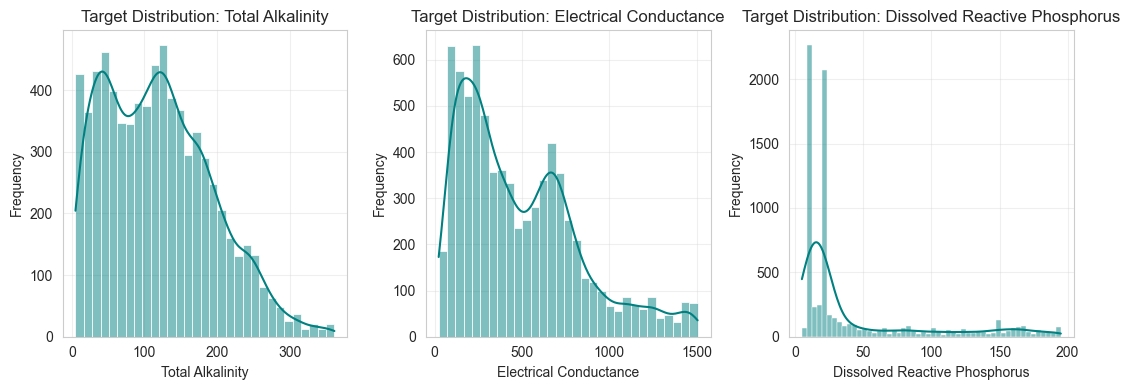

Top correlated feature candidates per target (Spearman abs corr):
- Total Alkalinity: []
- Electrical Conductance: []
- Dissolved Reactive Phosphorus: []


In [11]:
# Feature inventory + target analysis (optimized)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

num_cols = [c for c in num_cols if c not in TARGET_COL]
cat_cols = [c for c in cat_cols if c not in TARGET_COL]

print(f'Numeric feature count: {len(num_cols)}')
print(f'Categorical feature count: {len(cat_cols)}')

# Priority numeric set for downstream plots: lower missingness + higher variance
num_meta = pd.DataFrame(index=num_cols)
num_meta['missing_pct'] = df[num_cols].isnull().mean() * 100 if num_cols else []
num_meta['std'] = df[num_cols].std(numeric_only=True) if num_cols else []
num_meta = num_meta.sort_values(['missing_pct', 'std'], ascending=[True, False]) if len(num_meta) else num_meta
priority_num_cols = num_meta.index.tolist()[:MAX_NUM_PLOTS]

print(f'Priority numeric columns for plotting: {len(priority_num_cols)}')
display(num_meta.head(min(30, len(num_meta))))

# Target distributions
n_targets = len(TARGET_COL)
cols_per_row = 3
n_rows = (n_targets + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=safe_figsize(n_rows))
axes = np.array(axes).reshape(-1)

for idx, t_col in enumerate(TARGET_COL):
    sns.histplot(df[t_col].dropna(), kde=True, ax=axes[idx], color='teal')
    axes[idx].set_title(f'Target Distribution: {t_col}')
    axes[idx].set_xlabel(t_col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

for idx in range(n_targets, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# Precompute top correlated features per target (Spearman, sampled)
target_top_corr = {}
if num_cols:
    corr_frame = sample_rows(df[num_cols + TARGET_COL].dropna())
    corr_mat = corr_frame.corr(method='spearman')

    for t in TARGET_COL:
        if t not in corr_mat.columns:
            target_top_corr[t] = []
            continue

        s = corr_mat[t].drop(labels=[t], errors='ignore').dropna().abs().sort_values(ascending=False)
        target_top_corr[t] = s.head(MAX_SCATTER_FEATURES_PER_TARGET * 2).index.tolist()

    print('Top correlated feature candidates per target (Spearman abs corr):')
    for t in TARGET_COL:
        print(f'- {t}: {target_top_corr.get(t, [])[:6]}')


### Region Distribution

In [12]:
# Region distribution (count + percentage)
if "Region" in df.columns:
    region_counts = df["Region"].fillna("Missing").value_counts()
    region_pct = (region_counts / len(df) * 100).round(2)

    region_summary = pd.DataFrame({
        "Count": region_counts,
        "Percentage (%)": region_pct
    })

    display(region_summary)

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(
        x=region_summary.index,
        y=region_summary["Count"],
        hue=region_summary.index,
        palette="Set2",
        legend=False
    )
    ax.set_title("Region Distribution")
    ax.set_xlabel("Region")
    ax.set_ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.grid(True, axis="y", alpha=0.3)

    # label bars with percentages
    for i, (count, pct) in enumerate(zip(region_summary["Count"], region_summary["Percentage (%)"])):
        ax.text(i, count, f"{pct}%", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("Region column not found in df.")

Region column not found in df.


### Numeric Feature Distribution

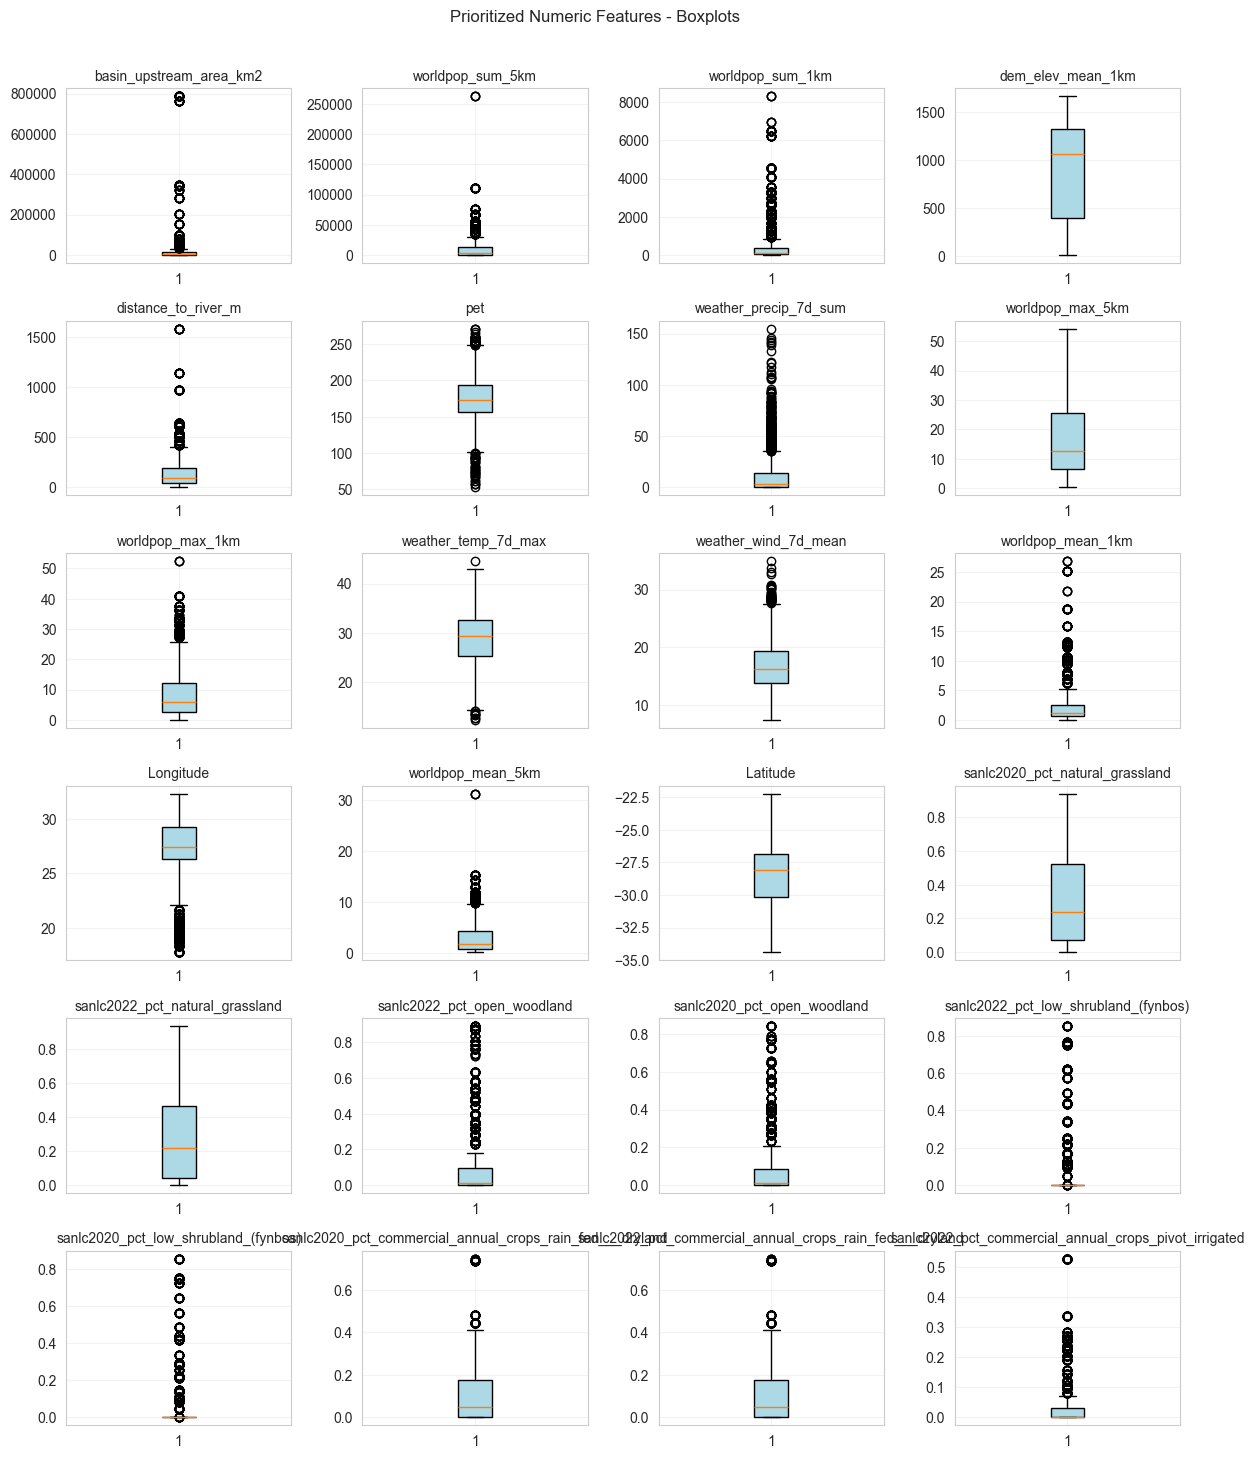

In [13]:
# Numeric boxplots on prioritized columns only
if priority_num_cols:
    plot_cols = priority_num_cols[:MAX_NUM_PLOTS]
    plot_df = sample_rows(df[plot_cols])

    cols_per_row = 4
    n_rows = (len(plot_cols) + cols_per_row - 1) // cols_per_row

    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=safe_figsize(n_rows, width=12, row_height=2.4, max_height=16))
    axes = np.array(axes).reshape(-1)

    for idx, col in enumerate(plot_cols):
        axes[idx].boxplot(plot_df[col].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
        axes[idx].set_title(col, fontsize=10)
        axes[idx].grid(True, alpha=0.25)

    for idx in range(len(plot_cols), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Prioritized Numeric Features - Boxplots', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No numeric columns available for boxplots.')


Top skewed numeric features:


,Feature,Skewness,Kurtosis,Abs_Skewness
53,sanlc2022_pct_residential_informal_(bare),22.890710,533.586988,22.890710
113,sanlc2020_pct_residential_informal_(bare),22.445099,518.758534,22.445099
135,sanlc2020_pct_artificial_flooded_mine_pits,20.064643,403.515016,20.064643
74,sanlc2022_pct_artificial_flooded_mine_pits,18.556495,356.796821,18.556495
133,sanlc2020_pct_residential_informal_(bush),17.342451,345.040424,17.342451
52,sanlc2022_pct_residential_informal_(low_veg___...,16.337294,322.347138,16.337294
111,sanlc2020_pct_residential_informal_(tree),15.843237,264.567633,15.843237
146,sanlc2020_pct_mine:_tailings_and_resource_dumps,14.350693,204.052520,14.350693
143,sanlc2022_pct_mine:_tailings_and_resource_dumps,14.349562,204.030771,14.349562
3,green,14.286234,262.747383,14.286234


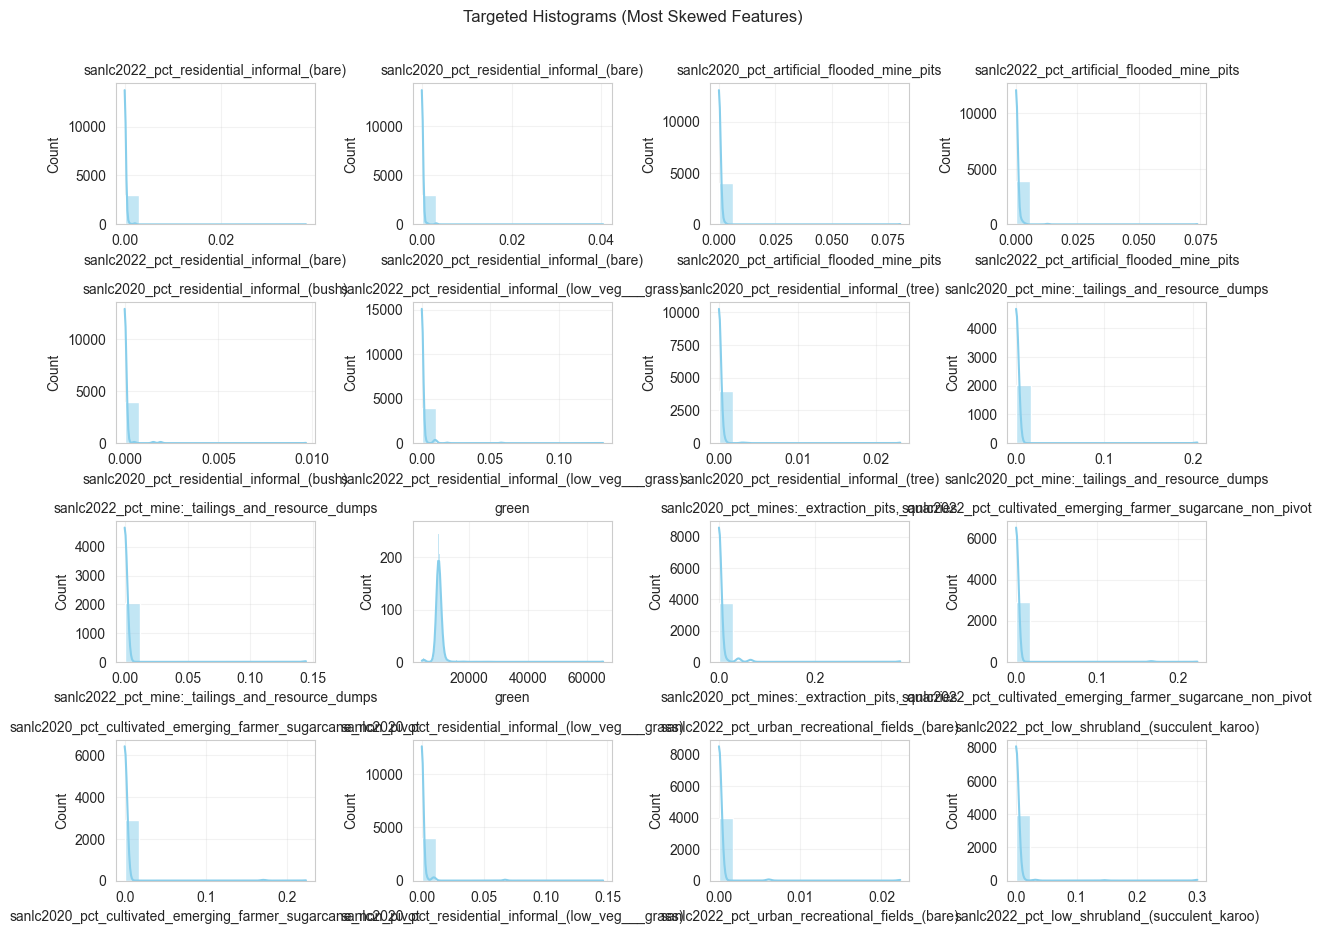

In [14]:
# Distribution diagnostics (skew/kurtosis + targeted histograms)
if num_cols:
    skew_series = df[num_cols].skew(numeric_only=True)
    kurt_series = df[num_cols].kurtosis(numeric_only=True)

    dist_df = pd.DataFrame({
        'Feature': skew_series.index,
        'Skewness': skew_series.values,
        'Kurtosis': kurt_series.reindex(skew_series.index).values,
    })
    dist_df['Abs_Skewness'] = dist_df['Skewness'].abs()
    dist_df = dist_df.sort_values('Abs_Skewness', ascending=False)

    print('Top skewed numeric features:')
    display(dist_df.head(25))

    hist_cols = [c for c in dist_df['Feature'].head(16).tolist() if c in df.columns]
    hist_df = sample_rows(df[hist_cols])

    cols_per_row = 4
    n_rows = (len(hist_cols) + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=safe_figsize(n_rows, width=12, row_height=2.3, max_height=14))
    axes = np.array(axes).reshape(-1)

    for idx, col in enumerate(hist_cols):
        sns.histplot(hist_df[col].dropna(), kde=True, ax=axes[idx], color='skyblue')
        axes[idx].set_title(col, fontsize=10)
        axes[idx].grid(True, alpha=0.25)

    for idx in range(len(hist_cols), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Targeted Histograms (Most Skewed Features)', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No numeric columns for distribution analysis.')


### Categorical Feature Distribution

Categorical feature cardinality summary:


,Feature,Unique_Values,Missing_%
0,Sample Date,1311,0.0


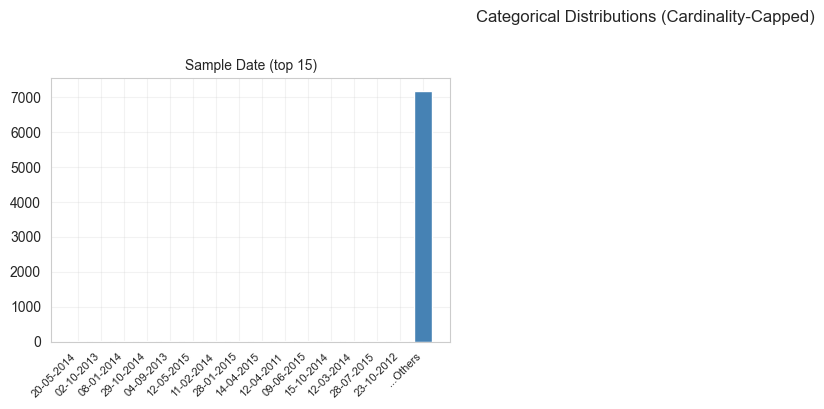

In [15]:
# Categorical distribution (high-cardinality aware)
if cat_cols:
    cat_cardinality = pd.DataFrame({
        'Feature': cat_cols,
        'Unique_Values': [df[c].nunique(dropna=True) for c in cat_cols],
        'Missing_%': [df[c].isna().mean() * 100 for c in cat_cols],
    }).sort_values('Unique_Values', ascending=False)

    print('Categorical feature cardinality summary:')
    display(cat_cardinality.head(25))

    cat_plot_cols = cat_cardinality['Feature'].head(MAX_CAT_PLOTS).tolist()

    cols_per_row = 3
    n_rows = (len(cat_plot_cols) + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=safe_figsize(n_rows, width=13, row_height=2.8, max_height=15))
    axes = np.array(axes).reshape(-1)

    max_categories = 15
    for idx, col in enumerate(cat_plot_cols):
        vc = df[col].astype(str).fillna('Missing').value_counts()
        if len(vc) > max_categories:
            vc = pd.concat([vc.head(max_categories), pd.Series({'...Others': vc.iloc[max_categories:].sum()})])

        axes[idx].bar(range(len(vc)), vc.values, color='steelblue')
        axes[idx].set_xticks(range(len(vc)))
        axes[idx].set_xticklabels(vc.index, rotation=45, ha='right', fontsize=8)
        axes[idx].set_title(f'{col} (top {max_categories})', fontsize=10)
        axes[idx].grid(True, alpha=0.25)

    for idx in range(len(cat_plot_cols), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Categorical Distributions (Cardinality-Capped)', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No categorical columns found.')


### Correlation Matrix

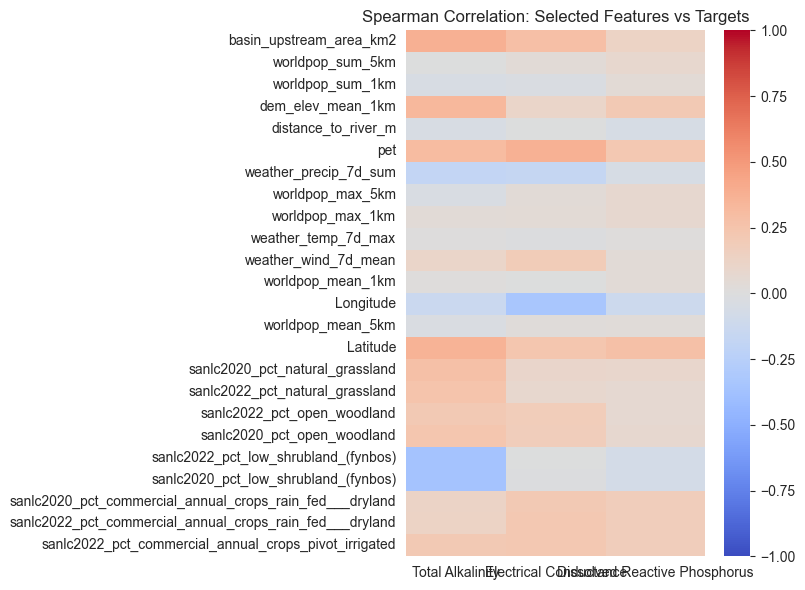

,target,feature,abs_spearman
24,Dissolved Reactive Phosphorus,Latitude,0.273527
25,Dissolved Reactive Phosphorus,pet,0.219532
26,Dissolved Reactive Phosphorus,dem_elev_mean_1km,0.215811
27,Dissolved Reactive Phosphorus,sanlc2022_pct_commercial_annual_crops_pivot_ir...,0.178892
28,Dissolved Reactive Phosphorus,sanlc2020_pct_commercial_annual_crops_rain_fed...,0.174637
29,Dissolved Reactive Phosphorus,sanlc2022_pct_commercial_annual_crops_rain_fed...,0.174174
30,Dissolved Reactive Phosphorus,basin_upstream_area_km2,0.126246
31,Dissolved Reactive Phosphorus,Longitude,0.124957
32,Dissolved Reactive Phosphorus,sanlc2020_pct_natural_grassland,0.087539
33,Dissolved Reactive Phosphorus,worldpop_sum_5km,0.082732


In [16]:
# Feature-target correlation (optimized)
if num_cols:
    corr_candidates = []
    for t in TARGET_COL:
        corr_candidates.extend(target_top_corr.get(t, []))

    corr_candidates = list(dict.fromkeys(corr_candidates))[:MAX_HEATMAP_FEATURES]

    if not corr_candidates:
        corr_candidates = priority_num_cols[:MAX_HEATMAP_FEATURES]

    corr_df = sample_rows(df[corr_candidates + TARGET_COL].dropna())
    feature_target_corr = corr_df.corr(method='spearman').loc[corr_candidates, TARGET_COL]

    plt.figure(figsize=(8, max(6, len(corr_candidates) * 0.25)))
    sns.heatmap(
        feature_target_corr,
        annot=(len(corr_candidates) <= 18),
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        center=0,
        fmt='.2f'
    )
    plt.title('Spearman Correlation: Selected Features vs Targets')
    plt.tight_layout()
    plt.show()

    rank_rows = []
    for t in TARGET_COL:
        s = feature_target_corr[t].abs().sort_values(ascending=False).head(12)
        for f, v in s.items():
            rank_rows.append({'target': t, 'feature': f, 'abs_spearman': float(v)})

    rank_df = pd.DataFrame(rank_rows).sort_values(['target', 'abs_spearman'], ascending=[True, False])
    display(rank_df)
else:
    print('No numeric columns available for correlation analysis.')


### Train-Test Drift Check (Optimized)


,feature,ks_stat,p_value,train_mean,test_mean
12,weather_temp_7d_max,0.030536,0.120576,28.952207,28.681170
21,sanlc2020_pct_open_woodland,0.029338,0.149391,0.084265,0.090055
7,distance_to_river_m,0.027316,0.210678,159.958623,159.545940
20,sanlc2022_pct_open_woodland,0.025190,0.293692,0.093415,0.101525
17,Latitude,0.022212,0.445694,-28.483813,-28.439689
2,Dissolved Reactive Phosphorus,0.021826,0.467746,43.236905,44.678916
16,worldpop_mean_5km,0.021701,0.475044,3.115002,3.210292
5,worldpop_sum_1km,0.020906,0.523282,568.599958,570.446202
8,pet,0.020000,0.582008,175.250398,174.828865
4,worldpop_sum_5km,0.019143,0.636119,10246.481377,10442.520426


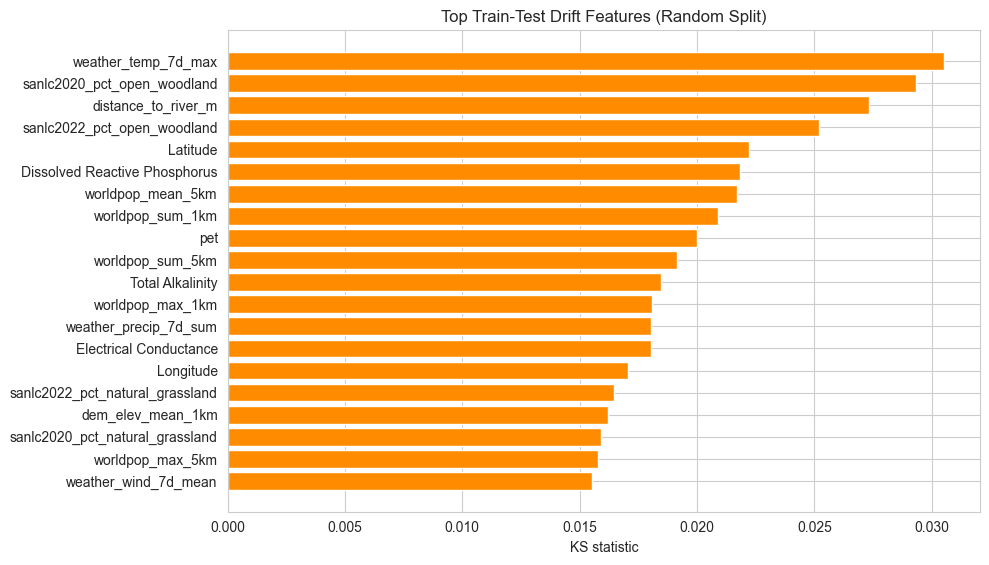

In [17]:
# Quick drift screen between train split and holdout split
# Uses KS statistic on numeric columns, prioritized for speed.

drift_cols = TARGET_COL + priority_num_cols[: min(20, len(priority_num_cols))]
rows = []

for col in drift_cols:
    a = df_train[col].dropna()
    b = df_test[col].dropna()

    if len(a) < 20 or len(b) < 20:
        continue

    ks_stat, p_val = ks_2samp(a, b)
    rows.append({
        'feature': col,
        'ks_stat': float(ks_stat),
        'p_value': float(p_val),
        'train_mean': float(a.mean()),
        'test_mean': float(b.mean()),
    })

if rows:
    drift_df = pd.DataFrame(rows).sort_values('ks_stat', ascending=False)
    display(drift_df.head(25))

    plt.figure(figsize=(10, max(4, min(25, len(drift_df)) * 0.25)))
    top = drift_df.head(20)
    plt.barh(top['feature'][::-1], top['ks_stat'][::-1], color='darkorange')
    plt.xlabel('KS statistic')
    plt.title('Top Train-Test Drift Features (Random Split)')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough data to compute drift diagnostics.')


### Missing Data Patterns

Columns with missing values: 34


,Missing %
sanlc2022_pct_land_fills,53.306506
sanlc2020_pct_land_fills,53.306506
sanlc2022_pct_mine:_tailings_and_resource_dumps,49.590879
sanlc2020_pct_mine:_tailings_and_resource_dumps,49.590879
sanlc2022_pct_cultivated_commercial_sugarcane_pivot_irrigated,49.590879
sanlc2020_pct_cultivated_commercial_sugarcane_pivot_irrigated,49.590879
sanlc2022_pct_natural_estuaries_&_lagoons,46.693494
sanlc2020_pct_natural_estuaries_&_lagoons,46.693494
sanlc2020_pct_low_shrubland_(nama_karoo),28.933602
sanlc2022_pct_low_shrubland_(nama_karoo),28.933602


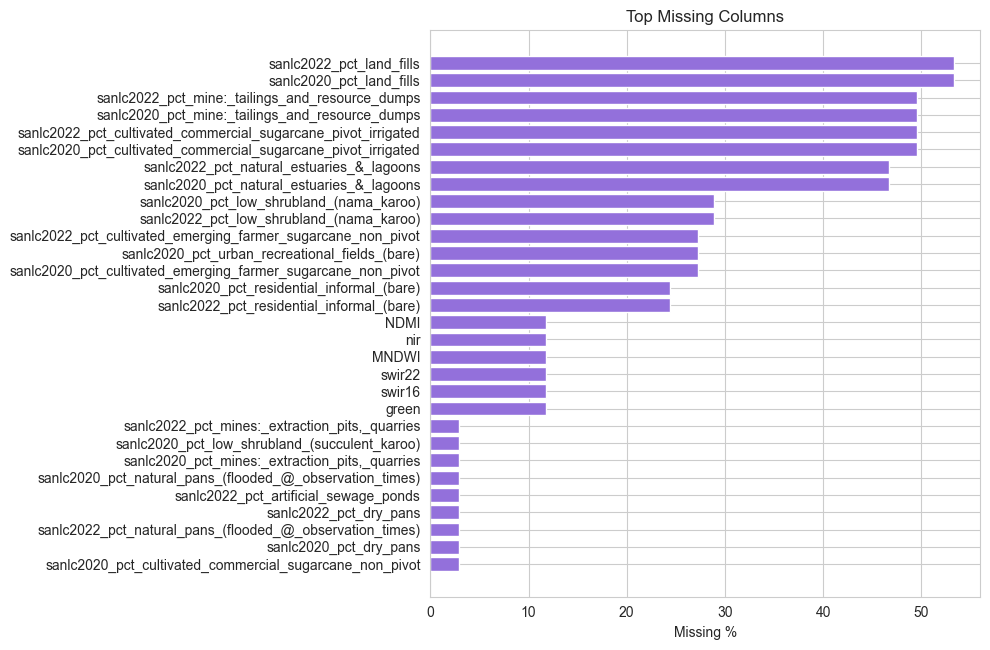

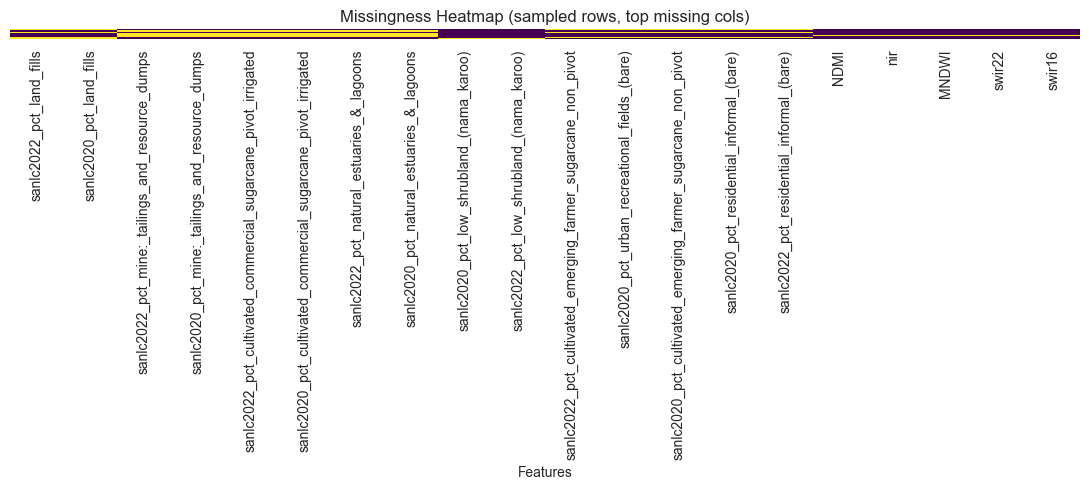

In [18]:
# Missing data patterns (optimized)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_nonzero = missing_pct[missing_pct > 0]

if missing_nonzero.empty:
    print('No missing data detected in the training set.')
else:
    print(f'Columns with missing values: {len(missing_nonzero)}')
    display(missing_nonzero.head(40).to_frame('Missing %'))

    # Top-missing bar chart
    top_miss = missing_nonzero.head(30)
    plt.figure(figsize=(10, max(4, len(top_miss) * 0.22)))
    plt.barh(top_miss.index[::-1], top_miss.values[::-1], color='mediumpurple')
    plt.xlabel('Missing %')
    plt.title('Top Missing Columns')
    plt.tight_layout()
    plt.show()

    # Sampled heatmap on top missing columns only
    heat_cols = top_miss.head(min(20, len(top_miss))).index.tolist()
    sampled_idx = sample_rows(df[heat_cols]).index
    plt.figure(figsize=(11, 5))
    sns.heatmap(df.loc[sampled_idx, heat_cols].isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title('Missingness Heatmap (sampled rows, top missing cols)')
    plt.xlabel('Features')
    plt.tight_layout()
    plt.show()


### Target Relationship Analysis

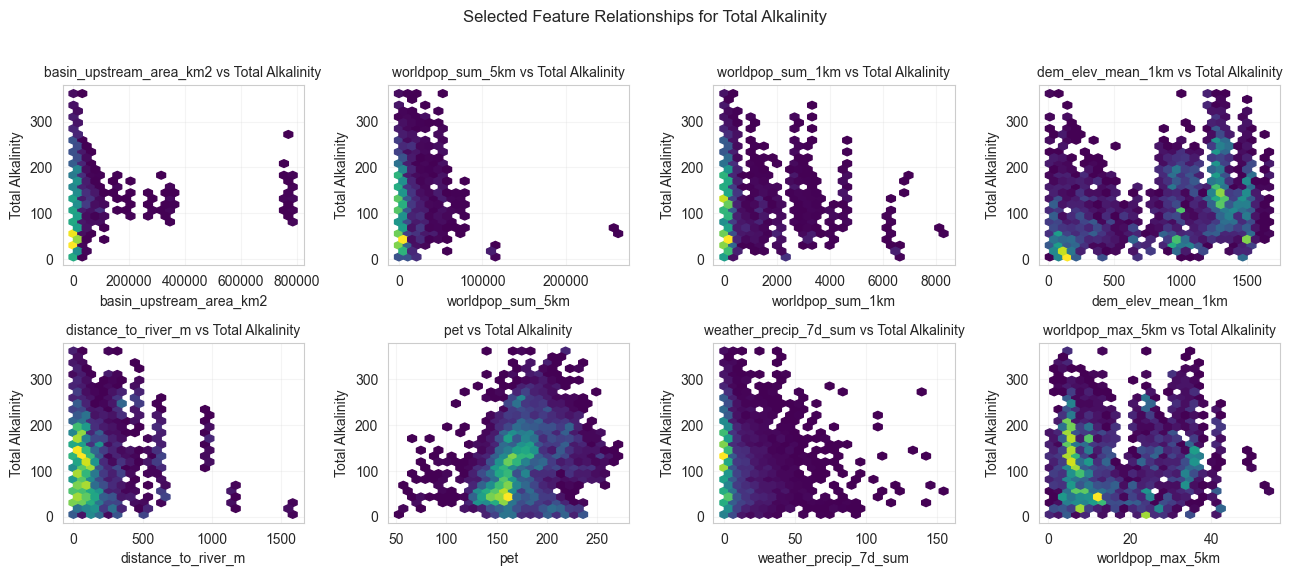

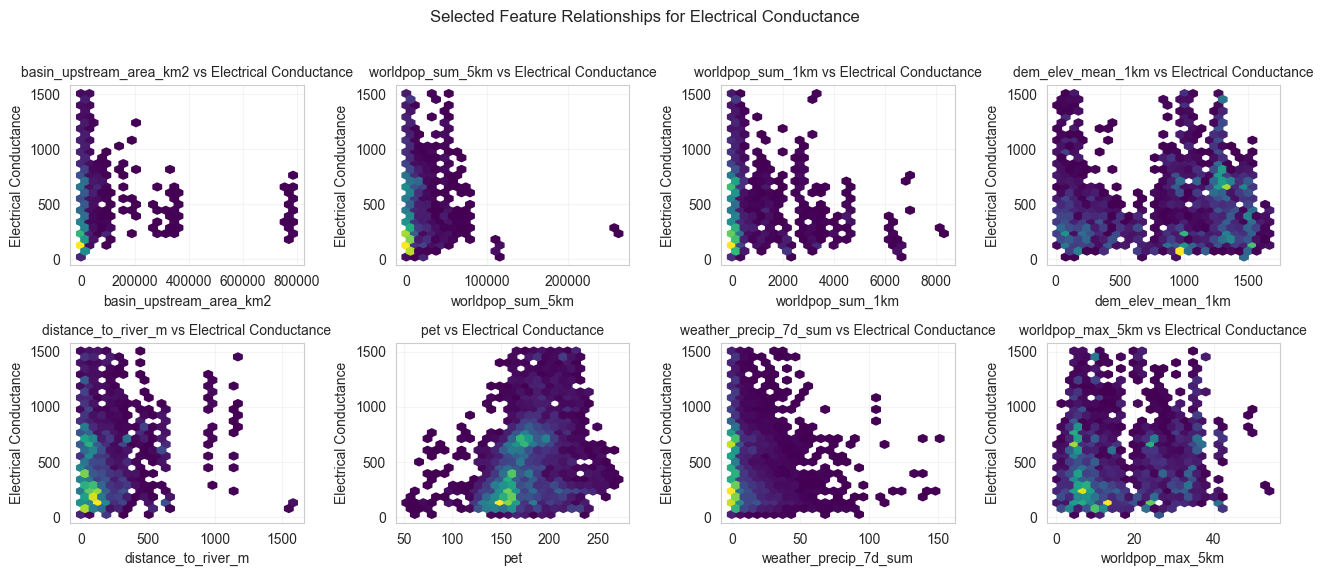

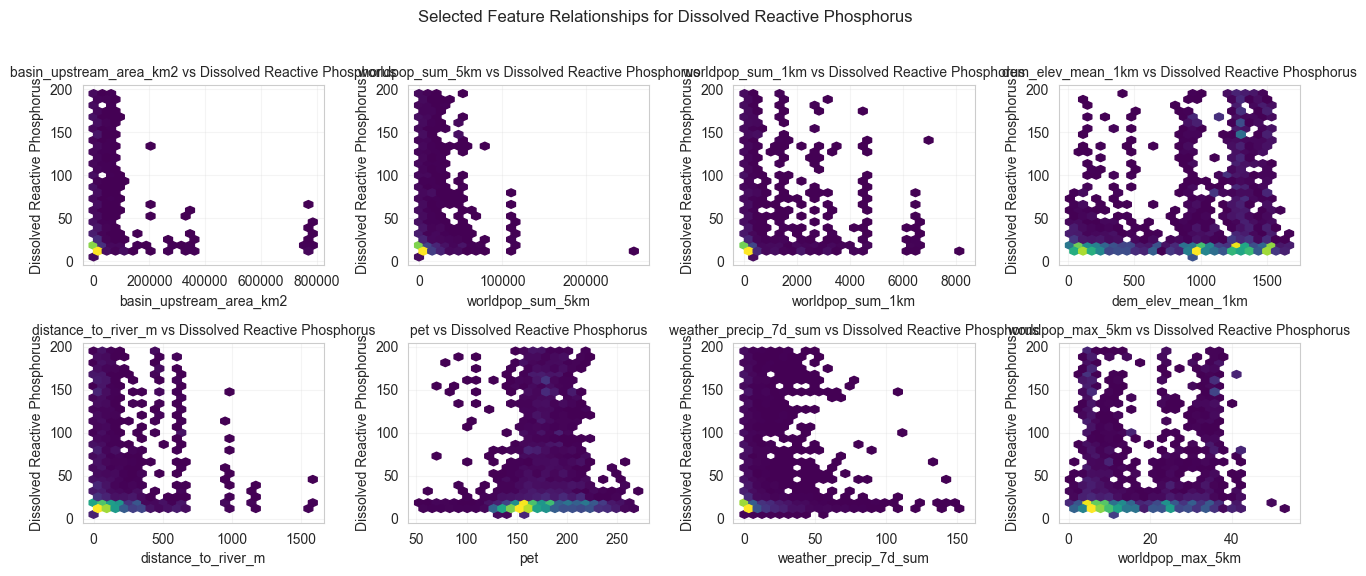

In [19]:
# Numeric Features vs Target (selected features only)
if num_cols and TARGET_COL:
    for t_col in TARGET_COL:
        selected = target_top_corr.get(t_col, [])[:MAX_SCATTER_FEATURES_PER_TARGET]
        if not selected:
            selected = priority_num_cols[:MAX_SCATTER_FEATURES_PER_TARGET]

        cols_per_row = 4
        n_rows = (len(selected) + cols_per_row - 1) // cols_per_row

        fig, axes = plt.subplots(
            n_rows,
            cols_per_row,
            figsize=safe_figsize(n_rows, width=13, row_height=2.8, max_height=14)
        )
        axes = np.array(axes).reshape(-1)

        for idx, col in enumerate(selected):
            ax = axes[idx]
            plot_df = sample_rows(df[[col, t_col]].dropna())

            hb = ax.hexbin(plot_df[col], plot_df[t_col], gridsize=25, cmap='viridis', mincnt=1)
            ax.set_xlabel(col)
            ax.set_ylabel(t_col)
            ax.set_title(f'{col} vs {t_col}', fontsize=10)
            ax.grid(True, alpha=0.2)

        for idx in range(len(selected), len(axes)):
            axes[idx].set_visible(False)

        fig.suptitle(f'Selected Feature Relationships for {t_col}', y=1.02)
        plt.tight_layout()
        plt.show()
else:
    print('No numeric features or target columns available for relationship plots.')


### Outlier Detection (IQR Method)

,Feature,Outlier Count,Outlier %,Lower Bound,Upper Bound
1,green,1161,15.57,7518.00,11830.00
16,worldpop_mean_1km,1019,13.67,-2.35,5.54
0,nir,1005,13.48,6004.25,20866.25
17,basin_upstream_area_km2,1003,13.45,-19227.45,36472.15
21,river_avg_discharge_cms,990,13.28,-36.13,64.45
3,swir22,944,12.66,3459.50,18179.50
2,swir16,931,12.49,2945.00,22505.00
8,total_precipitation,529,7.10,-24.32,41.47
10,soil_phh2o_mean_0_5cm,423,5.67,0.00,0.00
12,soil_sand_mean_0_5cm,415,5.57,0.00,0.00


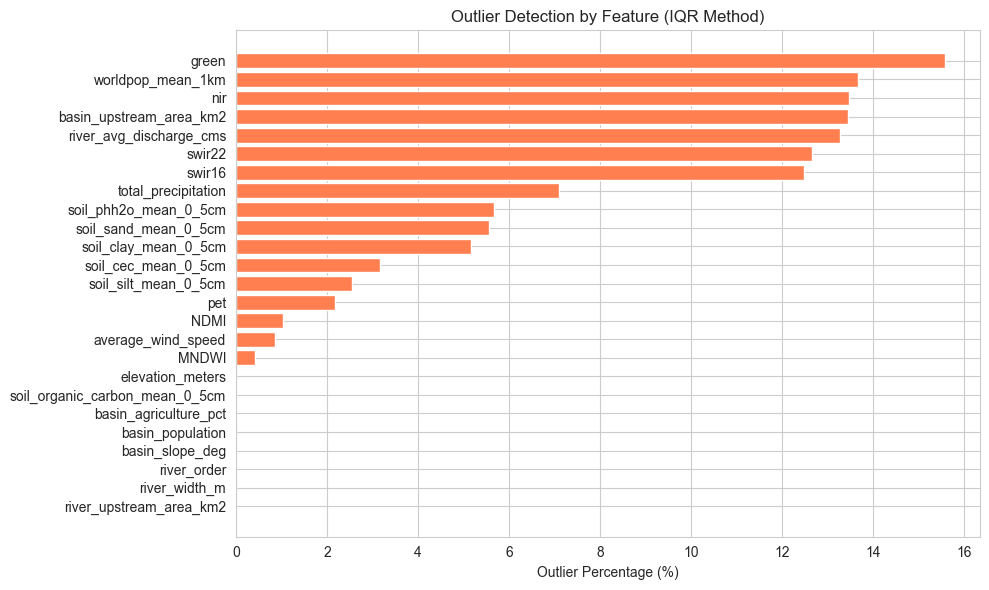

In [19]:
# Outlier detection (vectorized IQR)
if num_cols:
    num_df = df[num_cols]
    q1 = num_df.quantile(0.25)
    q3 = num_df.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_mask = (num_df.lt(lower, axis=1) | num_df.gt(upper, axis=1))
    outlier_count = outlier_mask.sum(axis=0)
    outlier_pct = (outlier_count / len(df) * 100).round(2)

    outlier_df = pd.DataFrame({
        'Feature': outlier_count.index,
        'Outlier Count': outlier_count.values,
        'Outlier %': outlier_pct.values,
        'Lower Bound': lower.reindex(outlier_count.index).values,
        'Upper Bound': upper.reindex(outlier_count.index).values,
    }).sort_values('Outlier %', ascending=False)

    display(outlier_df.head(40))

    top_outliers = outlier_df.head(20)
    plt.figure(figsize=(10, max(4, len(top_outliers) * 0.24)))
    plt.barh(top_outliers['Feature'][::-1], top_outliers['Outlier %'][::-1], color='coral')
    plt.xlabel('Outlier Percentage (%)')
    plt.title('Top Outlier Columns (IQR)')
    plt.tight_layout()
    plt.show()
else:
    print('No numeric columns to check for outliers.')


### Temporal Analysis (If Applicable)

Using date column: Sample_Date
Date range: 2011-01-02 to 2015-12-31


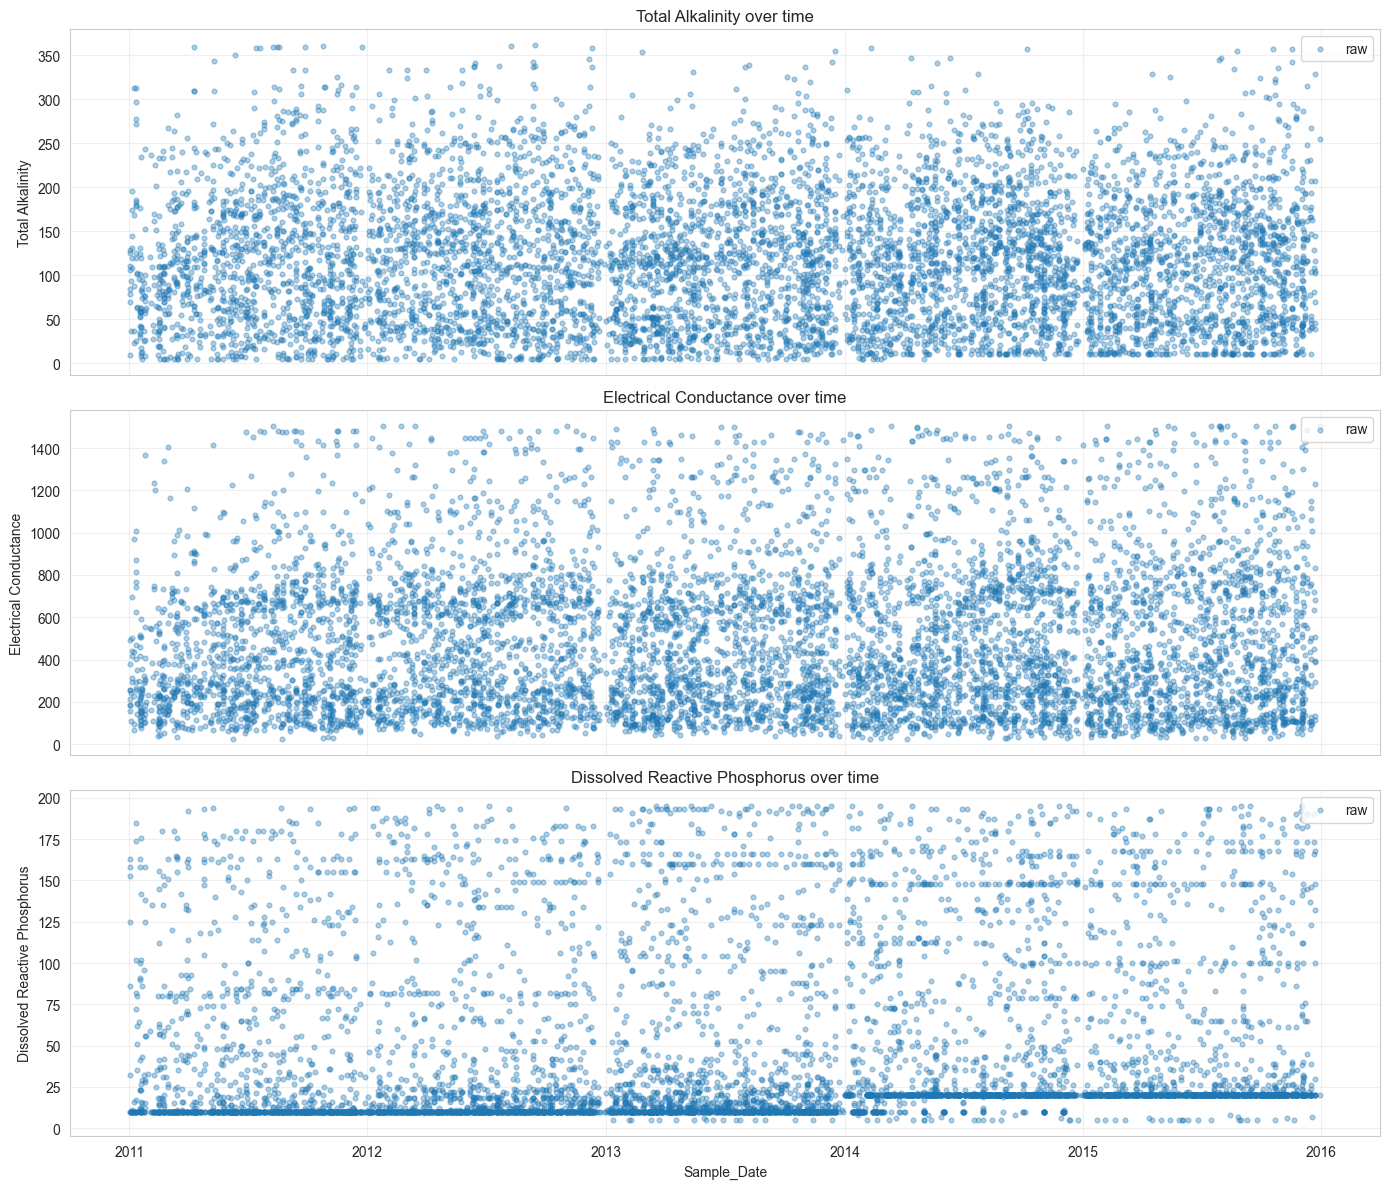

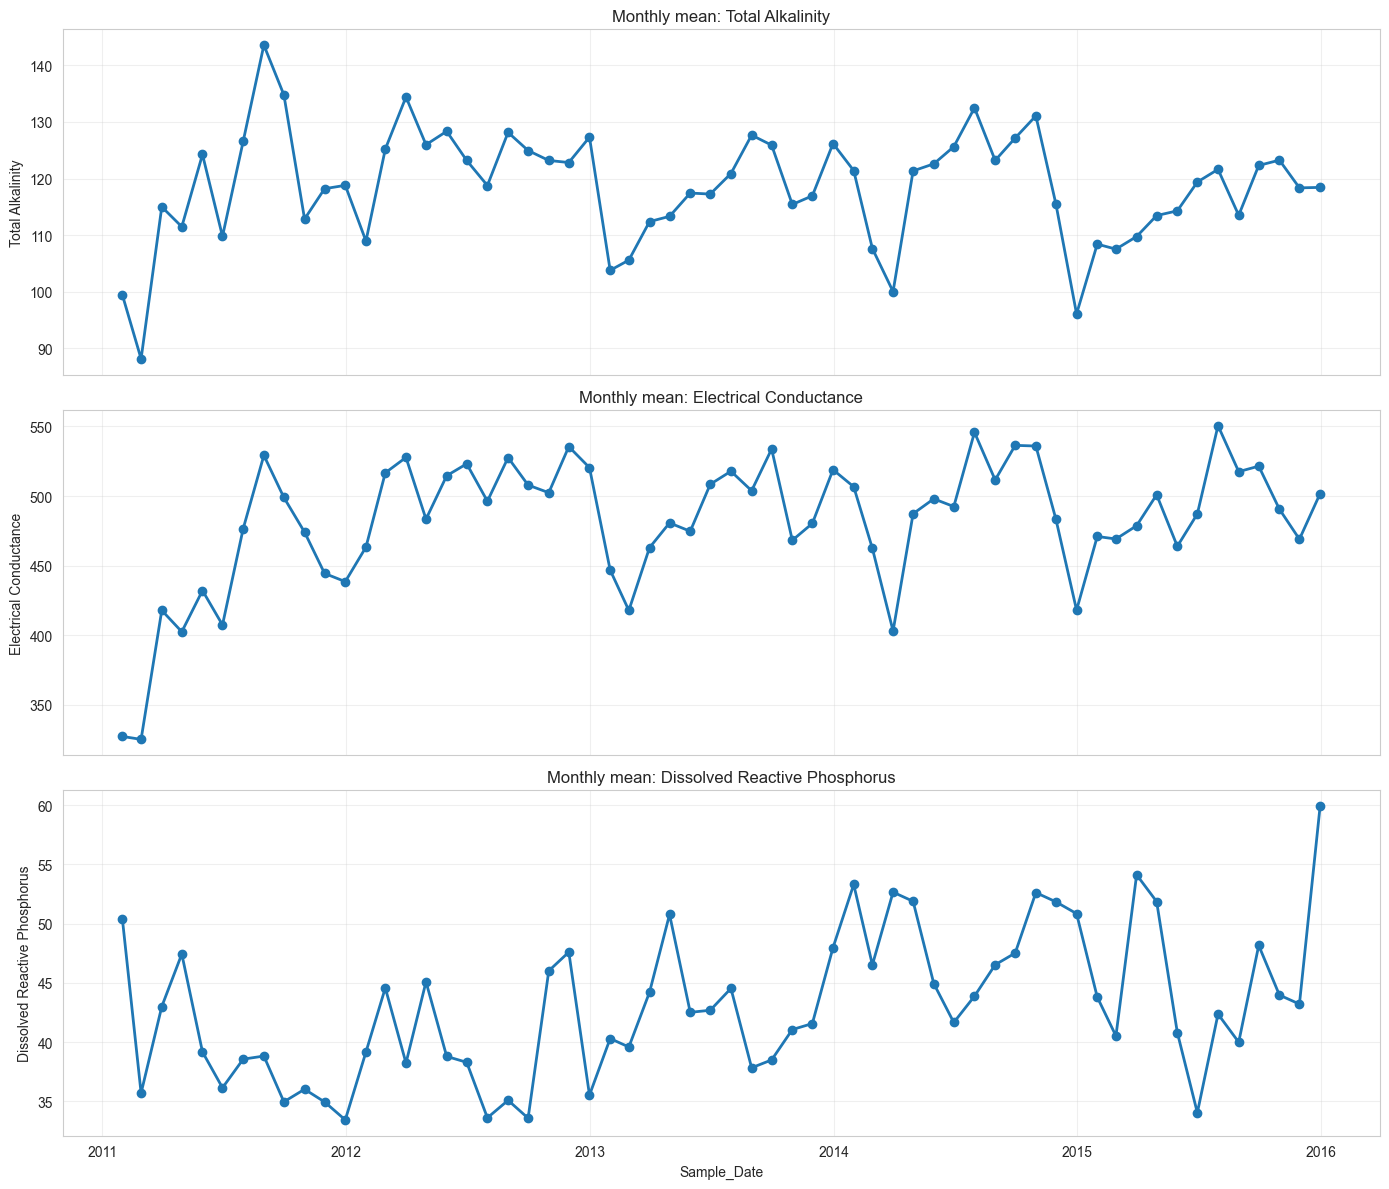

In [20]:
# Temporal analysis for multi-target regression
DATE_COL = "Sample_Date"

if DATE_COL in df.columns:
    # Safe datetime parse
    df_time = df.copy()
    df_time[DATE_COL] = pd.to_datetime(df_time[DATE_COL], errors="coerce", dayfirst=True)

    # Drop rows where date failed to parse
    df_time = df_time.dropna(subset=[DATE_COL]).sort_values(DATE_COL)

    if len(df_time) == 0:
        print(f"No valid datetime values found in '{DATE_COL}'.")
    else:
        print(f"Using date column: {DATE_COL}")
        print(f"Date range: {df_time[DATE_COL].min().date()} to {df_time[DATE_COL].max().date()}")

        # 1) Raw scatter per target over time
        n_targets = len(TARGET_COL)
        fig, axes = plt.subplots(n_targets, 1, figsize=(14, 4 * n_targets), sharex=True)
        axes = np.array(axes).reshape(-1)

        for i, t_col in enumerate(TARGET_COL):
            plot_df = df_time[[DATE_COL, t_col]].dropna()
            axes[i].scatter(plot_df[DATE_COL], plot_df[t_col], alpha=0.35, s=12, label="raw")
            axes[i].set_title(f"{t_col} over time")
            axes[i].set_ylabel(t_col)
            axes[i].grid(True, alpha=0.3)
            axes[i].legend(loc="upper right")

        axes[-1].set_xlabel(DATE_COL)
        plt.tight_layout()
        plt.show()

        # 2) Monthly trend per target (mean)
        monthly = (
            df_time.set_index(DATE_COL)[TARGET_COL]
            .resample("ME")
            .mean()
            .dropna(how="all")
        )

        if not monthly.empty:
            fig, axes = plt.subplots(n_targets, 1, figsize=(14, 4 * n_targets), sharex=True)
            axes = np.array(axes).reshape(-1)

            for i, t_col in enumerate(TARGET_COL):
                axes[i].plot(monthly.index, monthly[t_col], marker="o", linewidth=2)
                axes[i].set_title(f"Monthly mean: {t_col}")
                axes[i].set_ylabel(t_col)
                axes[i].grid(True, alpha=0.3)

            axes[-1].set_xlabel(DATE_COL)
            plt.tight_layout()
            plt.show()
        else:
            print("Not enough data to compute monthly trends.")
else:
    print("No temporal features detected. Set DATE_COL to your date column name.")

### Cardinality Check

In [ ]:
# # Identify high-cardinality categorical features
# if cat_cols:
#     cardinality_info = []
    
#     for col in cat_cols:
#         unique_count = df[col].nunique()
#         cardinality_pct = (unique_count / len(df)) * 100
        
#         cardinality_info.append({
#             'Feature': col,
#             'Unique Values': unique_count,
#             'Cardinality %': round(cardinality_pct, 2),
#             'Type': 'High' if unique_count > 50 else ('Medium' if unique_count > 10 else 'Low')
#         })
    
#     cardinality_df = pd.DataFrame(cardinality_info).sort_values(by='Unique Values', ascending=False)
#     display(cardinality_df)
    
#     # Flag high-cardinality features that may need special encoding
#     high_card_features = cardinality_df[cardinality_df['Type'] == 'High']['Feature'].tolist()
#     if high_card_features:
#         print(f"\n⚠️ High-cardinality features detected: {high_card_features}")
#         print("   Consider: Target encoding, frequency encoding, or feature hashing.")
# else:
#     print("No categorical columns to check for cardinality.")

### Class Imbalance Analysis

In [ ]:
# # Check for class imbalance (for classification tasks)
# if df[TARGET_COL].dtype == 'object' or df[TARGET_COL].nunique() < 20:
#     value_counts = df[TARGET_COL].value_counts()
#     value_pcts = df[TARGET_COL].value_counts(normalize=True) * 100
    
#     imbalance_df = pd.DataFrame({
#         'Class': value_counts.index,
#         'Count': value_counts.values,
#         'Percentage': [f"{pct:.2f}%" for pct in value_pcts.values]
#     })
    
#     print("Class Distribution:")
#     display(imbalance_df)
    
#     # Calculate imbalance ratio
#     if len(value_counts) == 2:
#         imbalance_ratio = value_counts.max() / value_counts.min()
#         print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
        
#         if imbalance_ratio > 3:
#             print("⚠️ Significant class imbalance detected!")
#             print("   Consider: SMOTE, class weights, or stratified sampling.")
    
#     # Visualization
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
#     # Count plot
#     axes[0].bar(range(len(value_counts)), value_counts.values, color='steelblue')
#     axes[0].set_xticks(range(len(value_counts)))
#     axes[0].set_xticklabels(value_counts.index, rotation=45)
#     axes[0].set_title('Class Distribution (Count)')
#     axes[0].set_ylabel('Count')
#     axes[0].grid(True, alpha=0.3)
    
#     # Pie chart
#     axes[1].pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%', startangle=90)
#     axes[1].set_title('Class Distribution (Percentage)')
    
#     plt.tight_layout()
#     plt.show()
# else:
#     print("Target variable is continuous (regression task). Class imbalance analysis not applicable.")

### Multicollinearity Check

In [21]:
# Multicollinearity check (subset + sampled for speed)
if len(num_cols) > 1:
    # Build a compact candidate set from strongest target-related features
    candidate = []
    for t in TARGET_COL:
        candidate.extend(target_top_corr.get(t, [])[:10])

    if not candidate:
        candidate = priority_num_cols[:VIF_MAX_FEATURES]

    candidate = list(dict.fromkeys(candidate))[:VIF_MAX_FEATURES]

    vif_data = df[candidate].dropna()
    vif_data = sample_rows(vif_data)

    if len(vif_data) > 0 and vif_data.shape[1] > 1:
        vif_values = []
        for i, col in enumerate(vif_data.columns):
            try:
                vif_val = variance_inflation_factor(vif_data.values, i)
            except Exception:
                vif_val = np.nan

            vif_values.append({'Feature': col, 'VIF': float(vif_val) if pd.notna(vif_val) else np.nan})

        vif_df = pd.DataFrame(vif_values).sort_values('VIF', ascending=False)
        display(vif_df)

        print('VIF interpretation: <5 low, 5-10 moderate, >10 high multicollinearity')

    print('=' * 50)
    print('High Correlation Pairs among VIF candidate set (|r| > 0.8):')
    print('=' * 50)

    corr_matrix = df[candidate].corr(method='spearman')
    high_corr_pairs = []

    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.8:
                high_corr_pairs.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': round(float(corr_val), 3),
                })

    if high_corr_pairs:
        high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=np.abs, ascending=False)
        display(high_corr_df)
    else:
        print('No high-correlation pairs detected in candidate set.')
else:
    print('Not enough numeric columns for multicollinearity analysis.')


,Feature,VIF
22,sanlc2022_pct_commercial_annual_crops_rain_fed...,288.224711
21,sanlc2020_pct_commercial_annual_crops_rain_fed...,287.402328
19,sanlc2022_pct_low_shrubland_(fynbos),142.805608
20,sanlc2020_pct_low_shrubland_(fynbos),139.687741
14,Latitude,137.811467
12,Longitude,83.738392
5,pet,68.998606
11,worldpop_mean_1km,49.964383
9,weather_temp_7d_max,41.269055
2,worldpop_sum_1km,29.276639


VIF interpretation: <5 low, 5-10 moderate, >10 high multicollinearity
High Correlation Pairs among VIF candidate set (|r| > 0.8):


,Feature 1,Feature 2,Correlation
8,sanlc2022_pct_low_shrubland_(fynbos),sanlc2020_pct_low_shrubland_(fynbos),1.000
9,sanlc2020_pct_commercial_annual_crops_rain_fed...,sanlc2022_pct_commercial_annual_crops_rain_fed...,0.998
5,worldpop_max_1km,worldpop_mean_1km,0.965
1,worldpop_sum_5km,worldpop_mean_5km,0.956
2,worldpop_sum_1km,worldpop_max_1km,0.955
3,worldpop_sum_1km,worldpop_mean_1km,0.954
4,worldpop_max_5km,worldpop_mean_5km,0.934
6,sanlc2020_pct_natural_grassland,sanlc2022_pct_natural_grassland,0.932
7,sanlc2022_pct_open_woodland,sanlc2020_pct_open_woodland,0.926
0,worldpop_sum_5km,worldpop_max_5km,0.919


### Geography Visualization

Latitude range: -34.4058 to -22.2256
Longitude range: 17.7303 to 32.3250
Date range: 2011-01-03 to 2015-12-31
Total sample points: 7455


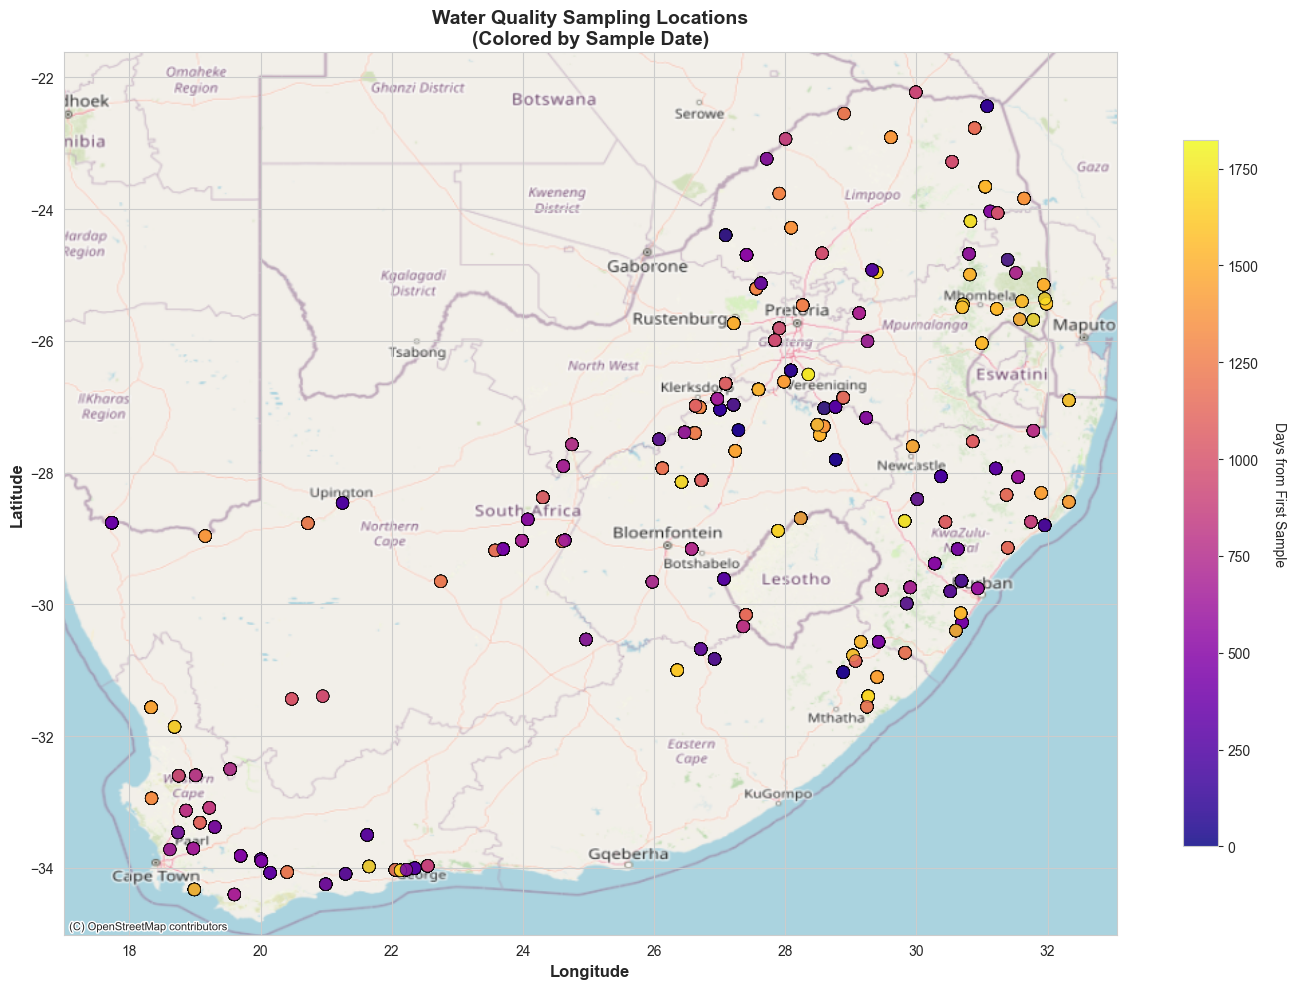

In [22]:
if 'Latitude' in df.columns and 'Longitude' in df.columns:
    
    df_geo = df[['Latitude', 'Longitude', 'Sample Date']].copy()
    df_geo = df_geo.dropna()
    
    df_geo['Sample Date'] = pd.to_datetime(df_geo['Sample Date'], errors='coerce', dayfirst=True)
    df_geo = df_geo.dropna(subset=['Sample Date'])
    
    # Convert dates to numeric for coloring
    date_numeric = (df_geo['Sample Date'] - df_geo['Sample Date'].min()).dt.days
    
    # Bounding box with padding
    lat_min, lat_max = df_geo['Latitude'].min(), df_geo['Latitude'].max()
    lon_min, lon_max = df_geo['Longitude'].min(), df_geo['Longitude'].max()
    lat_pad = (lat_max - lat_min) * 0.05
    lon_pad = (lon_max - lon_min) * 0.05
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Scatter plot colored by date
    scatter = ax.scatter(
        df_geo['Longitude'], 
        df_geo['Latitude'], 
        c=date_numeric, 
        cmap='plasma', 
        alpha=0.85, 
        s=80,
        edgecolors='black',
        linewidth=0.5,
        zorder=5
    )
    
    # Crop to data extent
    ax.set_xlim(lon_min - lon_pad, lon_max + lon_pad)
    ax.set_ylim(lat_min - lat_pad, lat_max + lat_pad)
    
    # Add static map tiles (must come after setting xlim/ylim)
    ctx.add_basemap(
        ax,
        crs='EPSG:4326',
        source=ctx.providers.OpenStreetMap.Mapnik,
        zoom='auto'
    )
    
    ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
    ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
    ax.set_title('Water Quality Sampling Locations\n(Colored by Sample Date)', fontsize=14, fontweight='bold')
    
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
    cbar.set_label('Days from First Sample', rotation=270, labelpad=20)
    
    print(f"Latitude range: {lat_min:.4f} to {lat_max:.4f}")
    print(f"Longitude range: {lon_min:.4f} to {lon_max:.4f}")
    print(f"Date range: {df_geo['Sample Date'].min().date()} to {df_geo['Sample Date'].max().date()}")
    print(f"Total sample points: {len(df_geo)}")
    
    plt.tight_layout()
    plt.show()

### Inspecting Validation File

In [25]:
VALIDATION_DATA_PATH = '../data/interim/master_test_iteration.parquet'
df_validation = pd.read_parquet(VALIDATION_DATA_PATH)

print(f"Validation data shape: {df_validation.shape}")
print("\n" + "="*70)
print("VALIDATION SET - BIRD'S EYE VIEW")
print("="*70 + "\n")

# Peek at the data (chunked columns)
chunk_size = 8

df_val_display = df_validation.copy()
num_val_cols = df_val_display.select_dtypes(include=[np.number]).columns
df_val_display[num_val_cols] = df_val_display[num_val_cols].round(4)

for i in range(0, df_val_display.shape[1], chunk_size):
    cols = df_val_display.columns[i:i + chunk_size]
    print(f"Preview columns {i+1} to {i + len(cols)}:")
    display(df_val_display[cols].head())

# Data types and missing values
print("Data types and missing values:")
val_info_df = pd.DataFrame({
    "Data Type": df_val_display.dtypes.astype(str),
    "Missing Values": df_val_display.isnull().sum(),
    "Missing %": (df_val_display.isnull().sum() / len(df_val_display) * 100).round(2),
    "Unique Values": df_val_display.nunique()
}).sort_values(by="Missing %", ascending=False)

display(val_info_df)

# Statistical summary in chunks
cols_1 = df_val_display.columns[0:6]
print("Describe columns 1 to 6:")
desc_1 = df_val_display[cols_1].describe(include="all").T
num_cols_1 = desc_1.select_dtypes(include="number").columns
display(desc_1.style.format({c: "{:.4f}" for c in num_cols_1}))

if df_val_display.shape[1] > 6:
    cols_2 = df_val_display.columns[6:12]
    print("Describe columns 7 to 12:")
    display(df_val_display[cols_2].describe(include="all").T.round(4))

if df_val_display.shape[1] > 12:
    cols_3 = df_val_display.columns[12:18]
    print("Describe columns 13 to 18:")
    display(df_val_display[cols_3].describe(include="all").T.round(4))


Validation data shape: (200, 130)

VALIDATION SET - BIRD'S EYE VIEW

Preview columns 1 to 8:


,Latitude,Longitude,Sample Date,Total Alkalinity,Electrical Conductance,Dissolved Reactive Phosphorus,Sample_Date,nir
0,-32.0433,27.8228,01-09-2014,NaN,NaN,NaN,2014-01-09,15229.0
1,-33.3292,26.0775,16-09-2015,NaN,NaN,NaN,2015-09-16,NaN
2,-32.9916,27.6400,07-05-2015,NaN,NaN,NaN,2015-07-05,16221.0
3,-34.0964,24.4392,07-02-2012,NaN,NaN,NaN,2012-07-02,NaN
4,-32.0006,28.5817,01-10-2014,NaN,NaN,NaN,2014-01-10,9125.0


Preview columns 9 to 16:


,green,swir16,swir22,NDMI,MNDWI,pet,elevation_meters,total_precipitation
0,12868.0,14797.0,12421.0,0.0144,-0.0697,161.9,781.0,17.6
1,NaN,NaN,NaN,NaN,NaN,177.6,261.0,3.8
2,9304.5,12536.5,9958.0,0.1281,-0.1480,158.4,154.0,2.0
3,NaN,NaN,NaN,NaN,NaN,130.0,17.0,9.2
4,11100.5,9455.0,8711.0,-0.0178,0.0801,152.5,349.0,20.1


Preview columns 17 to 24:


...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Latitude,200.000000,nan,nan,nan,-32.816735,0.652010,-34.096400,-33.185400,-32.991600,-32.086400,-31.903100
Longitude,200.000000,nan,nan,nan,26.583128,1.322306,24.196400,25.430000,27.366700,27.640000,28.581700
Sample Date,200,159,04-09-2014,3,nan,nan,nan,nan,nan,nan,nan
Total Alkalinity,0.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Electrical Conductance,0.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Dissolved Reactive Phosphorus,0.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


Describe columns 7 to 12:


,count,mean,min,25%,50%,75%,max,std
Sample_Date,200,2013-10-07 11:38:24,2011-01-14 00:00:00,2012-07-24 06:00:00,2014-01-29 12:00:00,2014-10-04 00:00:00,2015-12-28 00:00:00,NaN
nir,181.0,14462.955801,6281.0,13075.5,14525.5,16012.0,21308.0,2292.488853
green,181.0,9608.254144,4715.5,8939.0,9493.5,10243.5,13553.0,1070.355624
swir16,181.0,12332.01105,5173.5,10996.0,12425.5,13449.0,18512.5,2031.563618
swir22,181.0,10297.088398,4286.5,9157.5,9973.0,11138.5,16452.0,1702.497464
NDMI,181.0,0.079475,-0.1246,0.0299,0.0814,0.1312,0.2338,0.071918


Describe columns 13 to 18:


,count,mean,std,min,25%,50%,75%,max
MNDWI,181.0,-0.1200,0.0676,-0.2372,-0.1566,-0.1306,-0.1024,0.1397
pet,200.0,160.2780,25.3465,60.5000,140.7500,158.4000,173.7000,218.2000
elevation_meters,200.0,382.1350,334.9407,6.0000,145.0000,196.0000,781.0000,966.0000
total_precipitation,200.0,13.9805,16.8324,0.0000,1.9000,7.9000,20.2750,93.9000
average_wind_speed,200.0,20.0894,4.6767,9.1500,17.3188,19.1000,22.1688,36.4750
soil_phh2o_mean_0_5cm,200.0,5.9000,0.0000,5.9000,5.9000,5.9000,5.9000,5.9000



VALIDATION SET - GEOGRAPHY VISUALIZATION

Latitude range: -34.0964 to -31.9031
Longitude range: 24.1964 to 28.5817
Date range: 2011-01-14 to 2015-12-28
Total sample points: 200


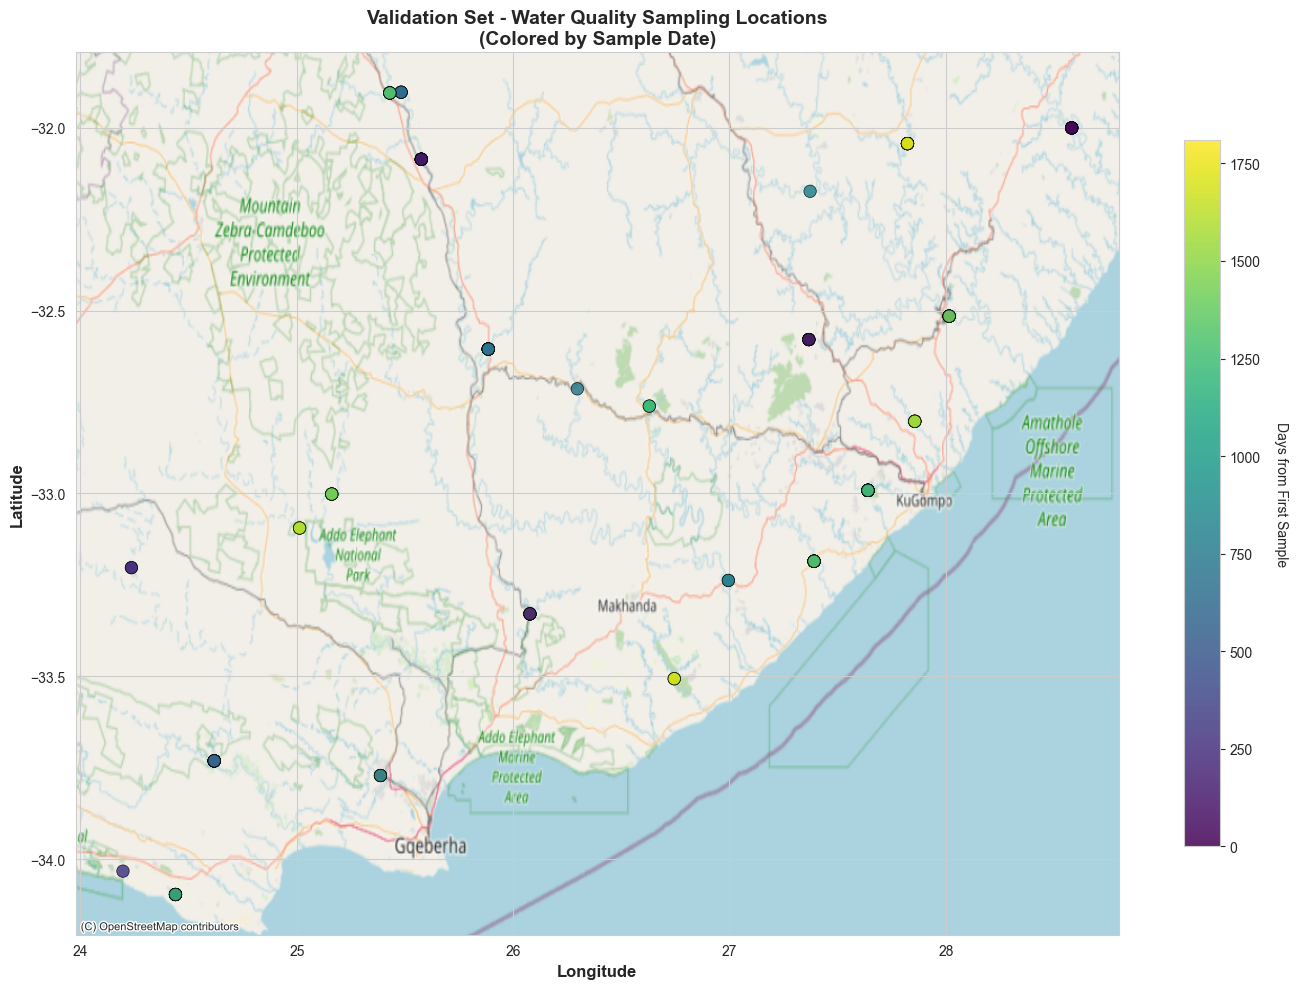

In [26]:
# Geography Visualization
print("\n" + "="*70)
print("VALIDATION SET - GEOGRAPHY VISUALIZATION")
print("="*70 + "\n")

if 'Latitude' in df_validation.columns and 'Longitude' in df_validation.columns:
    
    df_val_geo = df_validation[['Latitude', 'Longitude', 'Sample Date']].copy()
    df_val_geo = df_val_geo.dropna()
    
    df_val_geo['Sample Date'] = pd.to_datetime(df_val_geo['Sample Date'], errors='coerce', dayfirst=True)
    df_val_geo = df_val_geo.dropna(subset=['Sample Date'])
    
    # Convert dates to numeric for coloring
    date_numeric = (df_val_geo['Sample Date'] - df_val_geo['Sample Date'].min()).dt.days
    
    # Bounding box with padding
    lat_min, lat_max = df_val_geo['Latitude'].min(), df_val_geo['Latitude'].max()
    lon_min, lon_max = df_val_geo['Longitude'].min(), df_val_geo['Longitude'].max()
    lat_pad = (lat_max - lat_min) * 0.05
    lon_pad = (lon_max - lon_min) * 0.05
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Scatter plot colored by date
    scatter = ax.scatter(
        df_val_geo['Longitude'], 
        df_val_geo['Latitude'], 
        c=date_numeric, 
        cmap='viridis',  # Different color scheme to distinguish from training
        alpha=0.85, 
        s=80,
        edgecolors='black',
        linewidth=0.5,
        zorder=5
    )
    
    # Crop to data extent
    ax.set_xlim(lon_min - lon_pad, lon_max + lon_pad)
    ax.set_ylim(lat_min - lat_pad, lat_max + lat_pad)
    
    # Add static map tiles
    ctx.add_basemap(
        ax,
        crs='EPSG:4326',
        source=ctx.providers.OpenStreetMap.Mapnik,
        zoom='auto'
    )
    
    ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
    ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
    ax.set_title('Validation Set - Water Quality Sampling Locations\n(Colored by Sample Date)', 
                 fontsize=14, fontweight='bold')
    
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
    cbar.set_label('Days from First Sample', rotation=270, labelpad=20)
    
    print(f"Latitude range: {lat_min:.4f} to {lat_max:.4f}")
    print(f"Longitude range: {lon_min:.4f} to {lon_max:.4f}")
    print(f"Date range: {df_val_geo['Sample Date'].min().date()} to {df_val_geo['Sample Date'].max().date()}")
    print(f"Total sample points: {len(df_val_geo)}")
    
    plt.tight_layout()
    plt.show()
else:
    print("Latitude/Longitude columns not found in validation set.")

### SANLC Coverage And Schema Diagnostics


In [28]:
# SANLC diagnostics: train vs validation schema and coverage behavior
# Goal: confirm whether missing SANLC columns in validation are true absent classes
# and build a zero-filled aligned validation frame for downstream modeling.

sanlc_prefixes = ('sanlc2020_pct_', 'sanlc2022_pct_')

train_sanlc_cols = sorted([c for c in df.columns if c.startswith(sanlc_prefixes)])
valid_sanlc_cols = sorted([c for c in df_validation.columns if c.startswith(sanlc_prefixes)])

print(f'Train SANLC columns: {len(train_sanlc_cols)}')
print(f'Valid SANLC columns: {len(valid_sanlc_cols)}')

sanlc_train_only = sorted(set(train_sanlc_cols) - set(valid_sanlc_cols))
sanlc_valid_only = sorted(set(valid_sanlc_cols) - set(train_sanlc_cols))

print(f'SANLC in train only (missing in valid): {len(sanlc_train_only)}')
print(f'SANLC in valid only (missing in train): {len(sanlc_valid_only)}')

if sanlc_train_only:
    print()
    print('Sample SANLC columns missing in validation:')
    for c in sanlc_train_only[:25]:
        print('-', c)

if sanlc_valid_only:
    print()
    print('Sample SANLC columns only in validation:')
    for c in sanlc_valid_only[:25]:
        print('-', c)

# Create aligned validation copy with zero-filled missing SANLC columns
# This reflects "class absent in this geography" assumption for percent-cover features.
df_validation_sanlc_aligned = df_validation.copy()
for c in sanlc_train_only:
    df_validation_sanlc_aligned[c] = 0.0

# Keep same SANLC ordering as train for model consistency
df_validation_sanlc_aligned = df_validation_sanlc_aligned.reindex(
    columns=list(df_validation.columns) + [c for c in sanlc_train_only if c not in df_validation.columns]
)

print()
print('After alignment copy:')
print('Validation SANLC columns (aligned):', len([c for c in df_validation_sanlc_aligned.columns if c.startswith(sanlc_prefixes)]))

# Coverage summary for existing SANLC columns in each dataset
def sanlc_summary(frame: pd.DataFrame, sanlc_cols: list, label: str):
    if not sanlc_cols:
        print(f'No SANLC columns found for {label}.')
        return None

    local = frame[sanlc_cols].copy()
    desc = pd.DataFrame({
        'non_null_pct': (1 - local.isna().mean()) * 100,
        'zero_pct': (local.fillna(0).eq(0).mean()) * 100,
        'mean': local.mean(),
        'p95': local.quantile(0.95),
        'max': local.max(),
    }).sort_values(['zero_pct', 'mean'], ascending=[False, False])

    print()
    print(f'{label} SANLC column behavior (top 20 by zero_pct):')
    display(desc.head(20))

    return desc

train_sanlc_desc = sanlc_summary(df, train_sanlc_cols, 'Train')
valid_sanlc_desc = sanlc_summary(df_validation_sanlc_aligned, train_sanlc_cols, 'Valid (aligned to train SANLC set)')

# Row-wise coverage totals by year block (sanity check)
for year in ('2020', '2022'):
    ycols = [c for c in train_sanlc_cols if c.startswith(f'sanlc{year}_pct_')]
    if not ycols:
        continue

    train_sum = df[ycols].sum(axis=1, skipna=True)
    valid_sum = df_validation_sanlc_aligned[ycols].sum(axis=1, skipna=True)

    summary = pd.DataFrame({
        'dataset': ['train', 'valid_aligned'],
        'rows': [len(train_sum), len(valid_sum)],
        'mean_sum_pct': [float(train_sum.mean()), float(valid_sum.mean())],
        'p05_sum_pct': [float(train_sum.quantile(0.05)), float(valid_sum.quantile(0.05))],
        'p50_sum_pct': [float(train_sum.quantile(0.50)), float(valid_sum.quantile(0.50))],
        'p95_sum_pct': [float(train_sum.quantile(0.95)), float(valid_sum.quantile(0.95))],
    })

    print()
    print(f'SANLC {year} row-sum percentage summary:')
    display(summary)

# Suggested feature contract behavior
print()
print('Recommended contract before training/inference:')
print('1) Train defines SANLC schema contract.')
print('2) Add missing train SANLC columns to validation/test with 0.0.')
print('3) Drop SANLC columns not in train contract.')
print('4) Reorder validation/test columns to match train feature order exactly.')


Train SANLC columns: 130
Valid SANLC columns: 93
SANLC in train only (missing in valid): 37
SANLC in valid only (missing in train): 0

Sample SANLC columns missing in validation:
- sanlc2020_pct_artificial_flooded_mine_pits
- sanlc2020_pct_artificial_sewage_ponds
- sanlc2020_pct_cultivated_commercial_permanent_vines
- sanlc2020_pct_cultivated_commercial_sugarcane_non_pivot
- sanlc2020_pct_cultivated_commercial_sugarcane_pivot_irrigated
- sanlc2020_pct_cultivated_emerging_farmer_sugarcane_non_pivot
- sanlc2020_pct_dry_pans
- sanlc2020_pct_land_fills
- sanlc2020_pct_low_shrubland_(succulent_karoo)
- sanlc2020_pct_mine:_tailings_and_resource_dumps
- sanlc2020_pct_mines:_extraction_pits,_quarries
- sanlc2020_pct_natural_estuaries_&_lagoons
- sanlc2020_pct_natural_pans_(flooded_@_observation_times)
- sanlc2020_pct_residential_informal_(bush)
- sanlc2020_pct_residential_informal_(tree)
- sanlc2020_pct_smallholdings_(bare)
- sanlc2020_pct_smallholdings_(bush)
- sanlc2020_pct_smallholdings_(lo

,non_null_pct,zero_pct,mean,p95,max
sanlc2020_pct_mine:_tailings_and_resource_dumps,50.409121,99.664655,0.000985,0.000000,0.205200
sanlc2022_pct_mine:_tailings_and_resource_dumps,50.409121,99.664655,0.000694,0.000000,0.144150
sanlc2020_pct_cultivated_emerging_farmer_sugarcane_non_pivot,72.729712,99.557344,0.001148,0.000000,0.223768
sanlc2022_pct_cultivated_emerging_farmer_sugarcane_non_pivot,72.729712,99.557344,0.001131,0.000000,0.223768
sanlc2020_pct_cultivated_commercial_sugarcane_pivot_irrigated,50.409121,99.369551,0.002967,0.000000,0.297028
sanlc2022_pct_cultivated_commercial_sugarcane_pivot_irrigated,50.409121,99.369551,0.002961,0.000000,0.296391
sanlc2020_pct_land_fills,46.693494,98.698860,0.000071,0.000000,0.002550
sanlc2022_pct_land_fills,46.693494,98.698860,0.000007,0.000000,0.000255
sanlc2020_pct_natural_estuaries_&_lagoons,53.306506,98.081824,0.000549,0.000000,0.037089
sanlc2022_pct_natural_estuaries_&_lagoons,53.306506,98.081824,0.000524,0.000000,0.025890



Valid (aligned to train SANLC set) SANLC column behavior (top 20 by zero_pct):


,non_null_pct,zero_pct,mean,p95,max
sanlc2020_pct_artificial_flooded_mine_pits,100.0,100.0,0.0,0.0,0.0
sanlc2020_pct_artificial_sewage_ponds,100.0,100.0,0.0,0.0,0.0
sanlc2020_pct_cultivated_commercial_permanent_vines,100.0,100.0,0.0,0.0,0.0
sanlc2020_pct_cultivated_commercial_sugarcane_non_pivot,100.0,100.0,0.0,0.0,0.0
sanlc2020_pct_cultivated_commercial_sugarcane_pivot_irrigated,100.0,100.0,0.0,0.0,0.0
sanlc2020_pct_cultivated_emerging_farmer_sugarcane_non_pivot,100.0,100.0,0.0,0.0,0.0
sanlc2020_pct_dry_pans,100.0,100.0,0.0,0.0,0.0
sanlc2020_pct_land_fills,100.0,100.0,0.0,0.0,0.0
sanlc2020_pct_low_shrubland_(succulent_karoo),100.0,100.0,0.0,0.0,0.0
sanlc2020_pct_mine:_tailings_and_resource_dumps,100.0,100.0,0.0,0.0,0.0



SANLC 2020 row-sum percentage summary:


,dataset,rows,mean_sum_pct,p05_sum_pct,p50_sum_pct,p95_sum_pct
0,train,7455,1.0,1.0,1.0,1.0
1,valid_aligned,200,1.0,1.0,1.0,1.0



SANLC 2022 row-sum percentage summary:


,dataset,rows,mean_sum_pct,p05_sum_pct,p50_sum_pct,p95_sum_pct
0,train,7455,1.0,1.0,1.0,1.0
1,valid_aligned,200,1.0,1.0,1.0,1.0



Recommended contract before training/inference:
1) Train defines SANLC schema contract.
2) Add missing train SANLC columns to validation/test with 0.0.
3) Drop SANLC columns not in train contract.
4) Reorder validation/test columns to match train feature order exactly.


### Export Feature Contract For Preprocessing


In [29]:
# Export a reusable feature contract for 02_preprocessing.ipynb
# Contract is derived from full interim train (df_interim), excluding target columns.

from pathlib import Path
import json

CONTRACT_DIR = Path('../data/interim')
CONTRACT_DIR.mkdir(parents=True, exist_ok=True)

CONTRACT_TXT_PATH = CONTRACT_DIR / 'feature_contract_master_iteration.txt'
CONTRACT_META_PATH = CONTRACT_DIR / 'feature_contract_master_iteration_meta.json'

if 'TARGET_COL' not in globals():
    TARGET_COL = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']

if 'df_interim' not in globals():
    raise RuntimeError('df_interim is not loaded. Run the earlier data loading cells first.')

feature_contract_cols = [c for c in df_interim.columns if c not in TARGET_COL]

# Save plain text list (easy to paste/reuse)
CONTRACT_TXT_PATH.write_text('\n'.join(feature_contract_cols) + '\n', encoding='utf-8')

# Save metadata for safer reproducibility
dtype_map = {c: str(df_interim[c].dtype) for c in feature_contract_cols}
meta = {
    'source_dataset': str(INTERIM_DATA_PATH) if 'INTERIM_DATA_PATH' in globals() else 'unknown',
    'n_train_rows': int(len(df_interim)),
    'n_total_columns': int(df_interim.shape[1]),
    'n_feature_columns': int(len(feature_contract_cols)),
    'target_columns': TARGET_COL,
    'feature_columns': feature_contract_cols,
    'dtype_map': dtype_map,
    'sanlc_feature_count': int(sum(c.startswith(('sanlc2020_pct_', 'sanlc2022_pct_')) for c in feature_contract_cols)),
}

CONTRACT_META_PATH.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding='utf-8')

print('Feature contract exported.')
print('TXT :', CONTRACT_TXT_PATH)
print('META:', CONTRACT_META_PATH)
print('n_features:', len(feature_contract_cols))
print('sample columns:', feature_contract_cols[:8])


Feature contract exported.
TXT : ..\data\interim\feature_contract_master_iteration.txt
META: ..\data\interim\feature_contract_master_iteration_meta.json
n_features: 166
sample columns: ['Latitude', 'Longitude', 'Sample Date', 'Sample_Date', 'nir', 'green', 'swir16', 'swir22']


### Train vs Valid Data


TRAIN vs VALID COMPARISON (Latitude, Longitude, Sample Date)



,dataset,rows,lat_min,lat_max,lat_mean,lon_min,lon_max,lon_mean,date_min,date_max
0,train,7455,-34.405833,-22.225556,-28.483813,17.730278,32.325000,26.872603,2011-01-03,2015-12-31
1,valid,200,-34.096389,-31.903056,-32.816731,24.196389,28.581667,26.583118,2011-01-14,2015-12-28


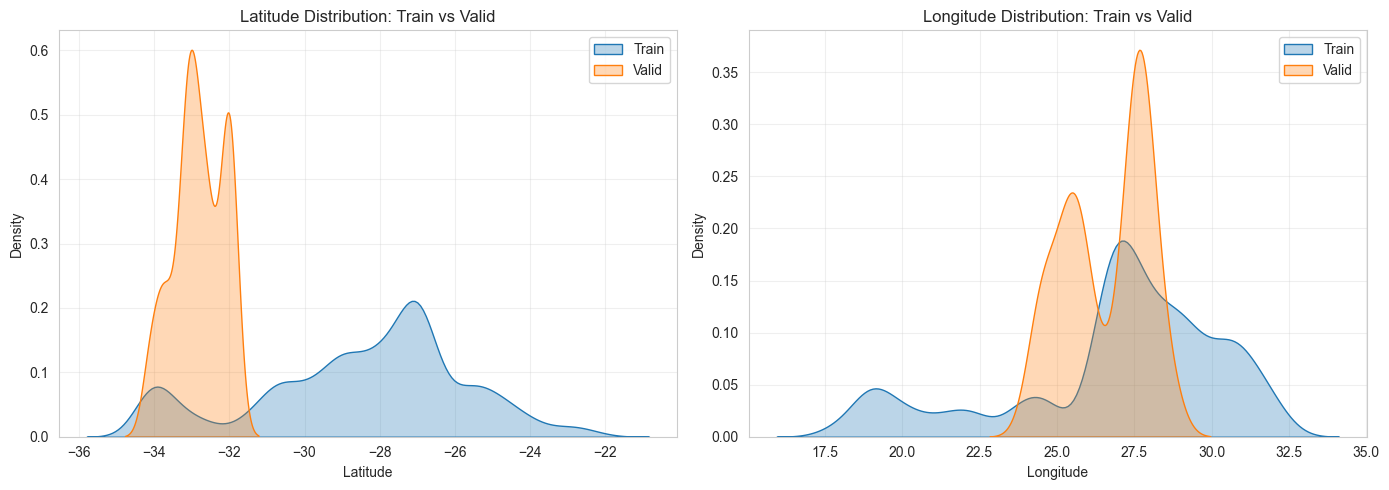

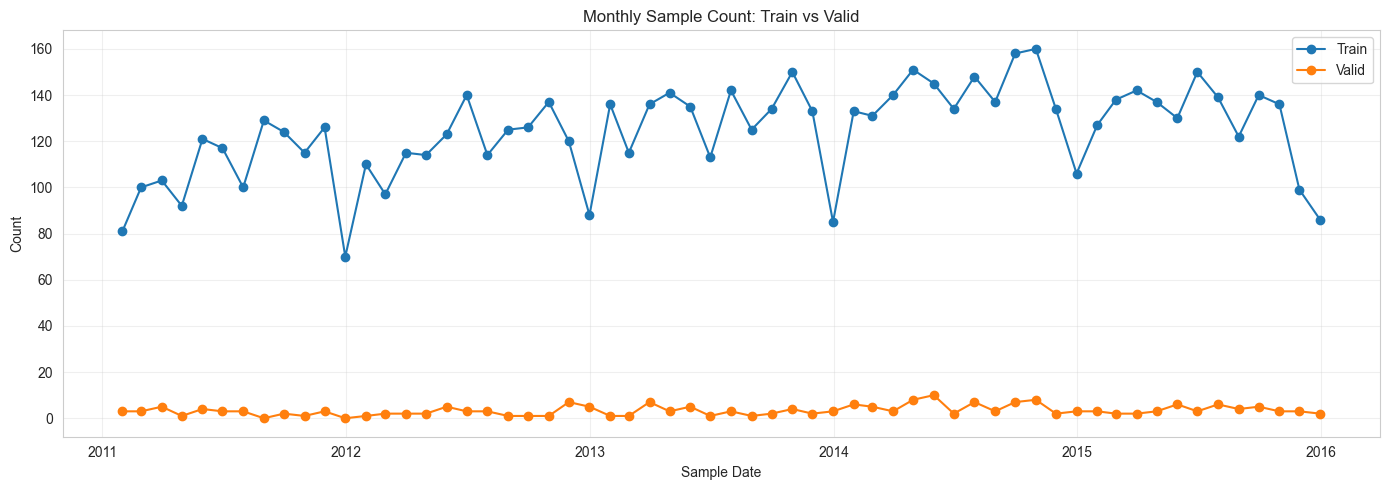

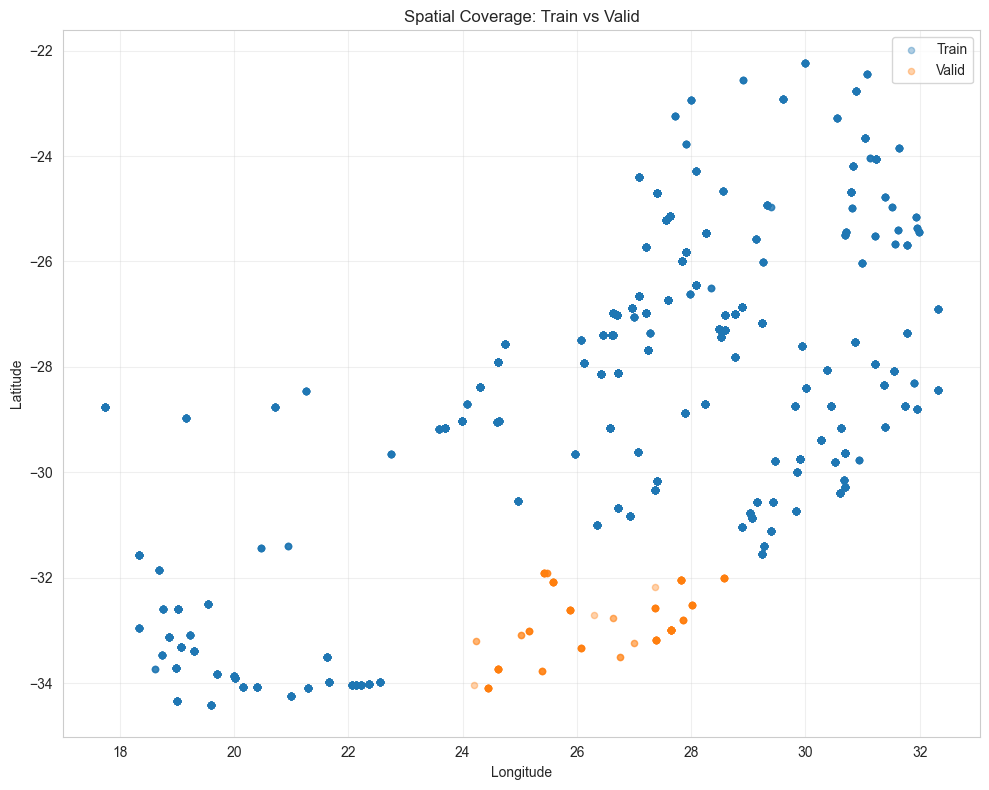

In [27]:
print("\n" + "=" * 70)
print("TRAIN vs VALID COMPARISON (Latitude, Longitude, Sample Date)")
print("=" * 70 + "\n")

DATE_COL = "Sample Date"
LAT_COL = "Latitude"
LON_COL = "Longitude"

# Build comparable subsets
train_cmp = df[[LAT_COL, LON_COL, DATE_COL]].copy()
valid_cmp = df_validation[[LAT_COL, LON_COL, DATE_COL]].copy()

for _df in (train_cmp, valid_cmp):
    _df[DATE_COL] = pd.to_datetime(_df[DATE_COL], errors="coerce", dayfirst=True)

train_cmp = train_cmp.dropna(subset=[LAT_COL, LON_COL, DATE_COL])
valid_cmp = valid_cmp.dropna(subset=[LAT_COL, LON_COL, DATE_COL])

# Summary table
summary = pd.DataFrame({
    "dataset": ["train", "valid"],
    "rows": [len(train_cmp), len(valid_cmp)],
    "lat_min": [train_cmp[LAT_COL].min(), valid_cmp[LAT_COL].min()],
    "lat_max": [train_cmp[LAT_COL].max(), valid_cmp[LAT_COL].max()],
    "lat_mean": [train_cmp[LAT_COL].mean(), valid_cmp[LAT_COL].mean()],
    "lon_min": [train_cmp[LON_COL].min(), valid_cmp[LON_COL].min()],
    "lon_max": [train_cmp[LON_COL].max(), valid_cmp[LON_COL].max()],
    "lon_mean": [train_cmp[LON_COL].mean(), valid_cmp[LON_COL].mean()],
    "date_min": [train_cmp[DATE_COL].min().date(), valid_cmp[DATE_COL].min().date()],
    "date_max": [train_cmp[DATE_COL].max().date(), valid_cmp[DATE_COL].max().date()],
})
display(summary)

# 1) Latitude/Longitude distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(train_cmp[LAT_COL], fill=True, alpha=0.30, label="Train", ax=axes[0], color="tab:blue")
sns.kdeplot(valid_cmp[LAT_COL], fill=True, alpha=0.30, label="Valid", ax=axes[0], color="tab:orange")
axes[0].set_title("Latitude Distribution: Train vs Valid")
axes[0].set_xlabel("Latitude")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sns.kdeplot(train_cmp[LON_COL], fill=True, alpha=0.30, label="Train", ax=axes[1], color="tab:blue")
sns.kdeplot(valid_cmp[LON_COL], fill=True, alpha=0.30, label="Valid", ax=axes[1], color="tab:orange")
axes[1].set_title("Longitude Distribution: Train vs Valid")
axes[1].set_xlabel("Longitude")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2) Sample date trend comparison (monthly count)
train_month = train_cmp.set_index(DATE_COL).resample("ME").size()
valid_month = valid_cmp.set_index(DATE_COL).resample("ME").size()

plt.figure(figsize=(14, 5))
plt.plot(train_month.index, train_month.values, marker="o", label="Train", color="tab:blue")
plt.plot(valid_month.index, valid_month.values, marker="o", label="Valid", color="tab:orange")
plt.title("Monthly Sample Count: Train vs Valid")
plt.xlabel("Sample Date")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3) Spatial overlay
plt.figure(figsize=(10, 8))
plt.scatter(train_cmp[LON_COL], train_cmp[LAT_COL], s=20, alpha=0.35, label="Train", color="tab:blue")
plt.scatter(valid_cmp[LON_COL], valid_cmp[LAT_COL], s=20, alpha=0.35, label="Valid", color="tab:orange")
plt.title("Spatial Coverage: Train vs Valid")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### LOSO Comparison

LOSO REGION DISTRIBUTION


,Train Count,Train %,Valid Count,Valid %
Region,,,,
Northern_Bulk,4661,62.5,0.0,0.0
Western_Cape,979,13.1,0.0,0.0
Eastern_Cape,1500,20.1,200.0,100.0


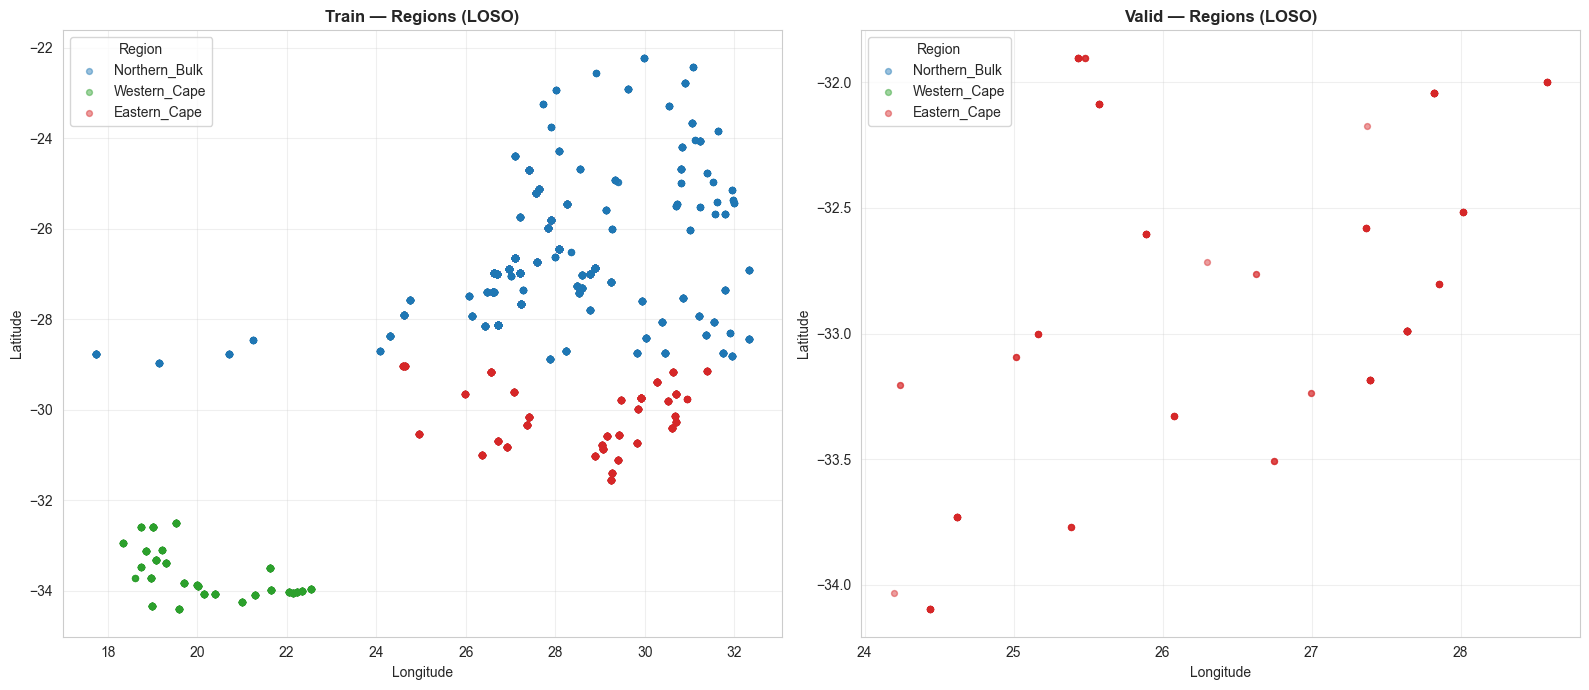

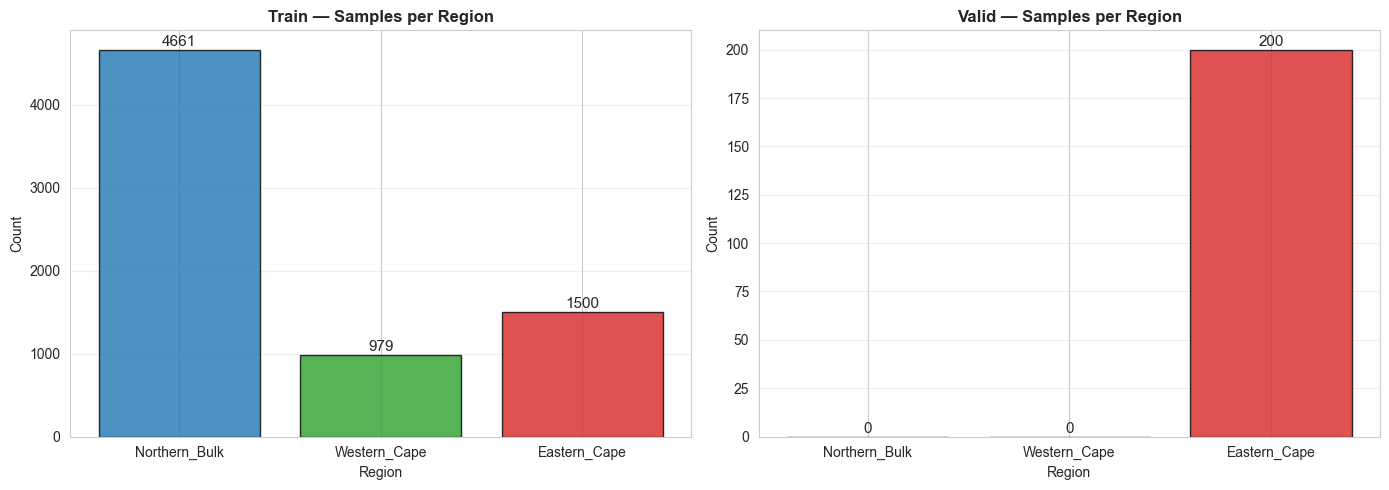

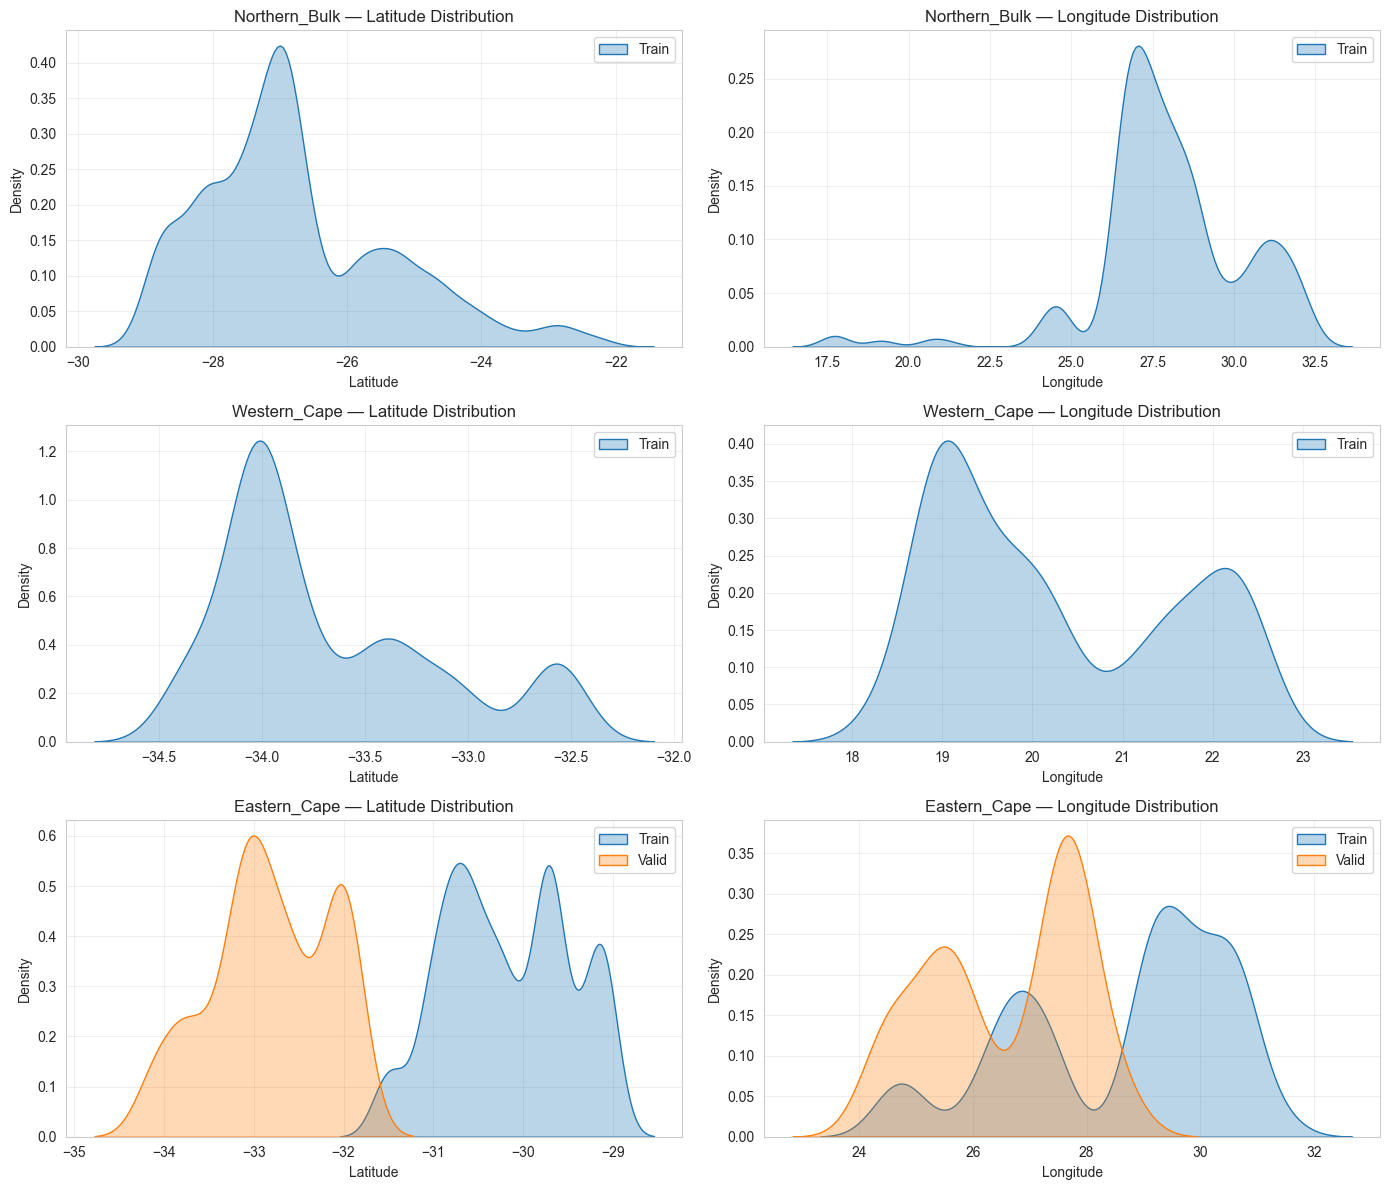

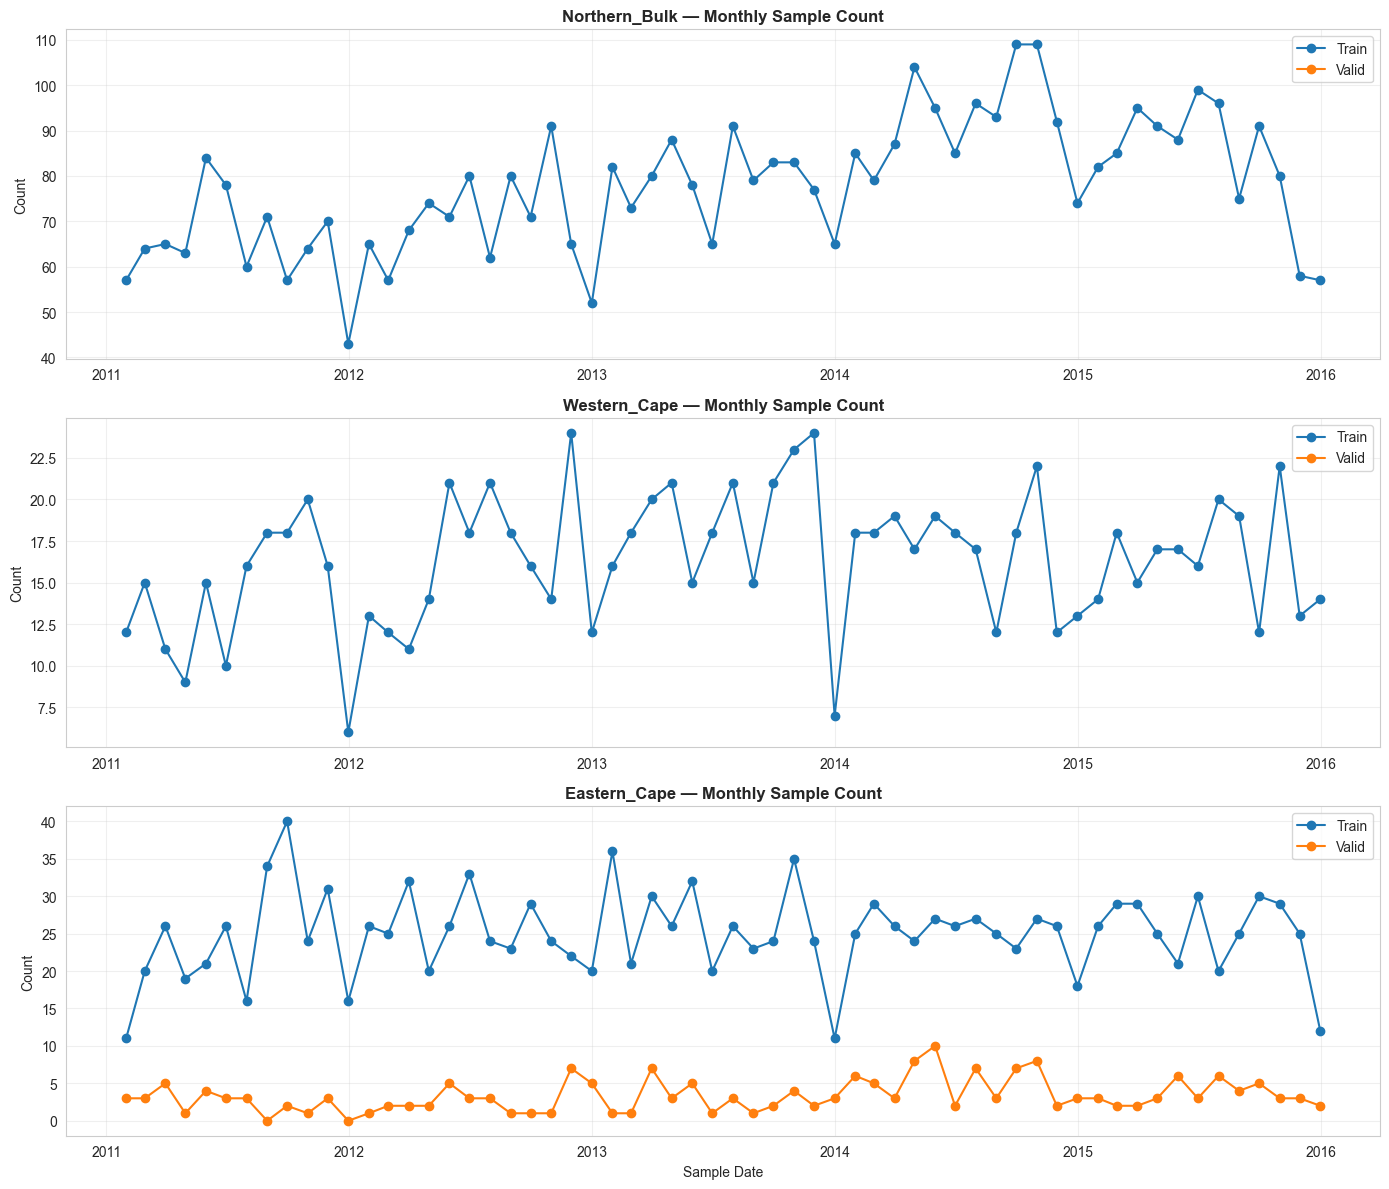


KS-TEST: DISTRIBUTION DRIFT (Train vs Valid per Region)


,Region,Feature,KS Stat,p-value,Drift?
0,Eastern_Cape,Latitude,1.0000,0.0,⚠️ Yes
1,Eastern_Cape,Longitude,0.6433,0.0,⚠️ Yes


In [ ]:
# def assign_region(row):
#     lat, lon = row['Latitude'], row['Longitude']
    
#     # True Cape Fold Belt / Mediterranean zone
#     if lat <= -32.0 and lon < 24.0:
#         return 'Western_Cape'
    
#     # Highveld / Limpopo plateau
#     elif lat >= -29.0:
#         return 'Northern_Bulk'
    
#     # Eastern Cape / Karoo transitional (your hardest zone)
#     elif lat < -29.0 and lon >= 24.0:
#         return 'Eastern_Cape'
    
#     # Karoo interior buffer — currently being split ambiguously
#     else:
#         return 'Karoo_Buffer'  # Consider adding a 4th region

# DATE_COL = "Sample Date"
# LAT_COL = "Latitude"
# LON_COL = "Longitude"

# # ── Assign regions ────────────────────────────────────────────────────────────
# train_loso = df[[LAT_COL, LON_COL, DATE_COL]].copy()
# valid_loso = df_validation[[LAT_COL, LON_COL, DATE_COL]].copy()

# for _df in (train_loso, valid_loso):
#     _df[DATE_COL] = pd.to_datetime(_df[DATE_COL], errors="coerce", dayfirst=True)

# train_loso = train_loso.dropna(subset=[LAT_COL, LON_COL, DATE_COL])
# valid_loso = valid_loso.dropna(subset=[LAT_COL, LON_COL, DATE_COL])

# train_loso["Region"] = train_loso.apply(assign_region, axis=1)
# valid_loso["Region"] = valid_loso.apply(assign_region, axis=1)

# REGIONS = ["Northern_Bulk", "Western_Cape", "Eastern_Cape"]
# COLORS   = {"Northern_Bulk": "tab:blue", "Western_Cape": "tab:green", "Eastern_Cape": "tab:red"}

# # ── 1) Region count summary ───────────────────────────────────────────────────
# print("=" * 70)
# print("LOSO REGION DISTRIBUTION")
# print("=" * 70)

# region_summary = pd.DataFrame({
#     "Train Count":  train_loso["Region"].value_counts(),
#     "Train %":      (train_loso["Region"].value_counts(normalize=True) * 100).round(1),
#     "Valid Count":  valid_loso["Region"].value_counts(),
#     "Valid %":      (valid_loso["Region"].value_counts(normalize=True) * 100).round(1),
# }).loc[REGIONS].fillna(0)

# display(region_summary)

# # ── 2) Spatial scatter coloured by region ────────────────────────────────────
# fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# for ax, (loso_df, title) in zip(axes, [
#     (train_loso, "Train — Regions (LOSO)"),
#     (valid_loso, "Valid — Regions (LOSO)"),
# ]):
#     for region in REGIONS:
#         subset = loso_df[loso_df["Region"] == region]
#         ax.scatter(subset[LON_COL], subset[LAT_COL],
#                    s=18, alpha=0.45, label=region, color=COLORS[region])
#     ax.set_title(title, fontweight="bold")
#     ax.set_xlabel("Longitude")
#     ax.set_ylabel("Latitude")
#     ax.legend(title="Region")
#     ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # ── 3) Region count bar chart ─────────────────────────────────────────────────
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# for ax, (loso_df, title) in zip(axes, [
#     (train_loso, "Train — Samples per Region"),
#     (valid_loso, "Valid — Samples per Region"),
# ]):
#     counts = loso_df["Region"].value_counts().reindex(REGIONS, fill_value=0)
#     ax.bar(counts.index, counts.values,
#            color=[COLORS[r] for r in counts.index], edgecolor="black", alpha=0.8)
#     for i, v in enumerate(counts.values):
#         ax.text(i, v + counts.values.max() * 0.01, str(v), ha="center", fontsize=11)
#     ax.set_title(title, fontweight="bold")
#     ax.set_ylabel("Count")
#     ax.set_xlabel("Region")
#     ax.grid(True, alpha=0.3, axis="y")

# plt.tight_layout()
# plt.show()

# # ── 4) Lat / Lon KDE per region ───────────────────────────────────────────────
# fig, axes = plt.subplots(len(REGIONS), 2, figsize=(14, 4 * len(REGIONS)))

# for row_idx, region in enumerate(REGIONS):
#     tr = train_loso[train_loso["Region"] == region]
#     va = valid_loso[valid_loso["Region"] == region]

#     for col_idx, (col, label) in enumerate([(LAT_COL, "Latitude"), (LON_COL, "Longitude")]):
#         ax = axes[row_idx, col_idx]
#         if len(tr) > 1:
#             sns.kdeplot(tr[col], fill=True, alpha=0.30, label="Train",
#                         ax=ax, color="tab:blue")
#         if len(va) > 1:
#             sns.kdeplot(va[col], fill=True, alpha=0.30, label="Valid",
#                         ax=ax, color="tab:orange")
#         ax.set_title(f"{region} — {label} Distribution")
#         ax.set_xlabel(label)
#         ax.legend()
#         ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # ── 5) Monthly sample count per region ───────────────────────────────────────
# fig, axes = plt.subplots(len(REGIONS), 1, figsize=(14, 4 * len(REGIONS)), sharex=False)

# for idx, region in enumerate(REGIONS):
#     tr_month = (train_loso[train_loso["Region"] == region]
#                 .set_index(DATE_COL).resample("ME").size())
#     va_month = (valid_loso[valid_loso["Region"] == region]
#                 .set_index(DATE_COL).resample("ME").size())

#     axes[idx].plot(tr_month.index, tr_month.values, marker="o",
#                    label="Train", color="tab:blue")
#     axes[idx].plot(va_month.index, va_month.values, marker="o",
#                    label="Valid", color="tab:orange")
#     axes[idx].set_title(f"{region} — Monthly Sample Count", fontweight="bold")
#     axes[idx].set_ylabel("Count")
#     axes[idx].legend()
#     axes[idx].grid(True, alpha=0.3)

# axes[-1].set_xlabel("Sample Date")
# plt.tight_layout()
# plt.show()

# # ── 6) KS-test drift summary per region ──────────────────────────────────────
# print("\n" + "=" * 70)
# print("KS-TEST: DISTRIBUTION DRIFT (Train vs Valid per Region)")
# print("=" * 70)

# ks_rows = []
# for region in REGIONS:
#     tr = train_loso[train_loso["Region"] == region]
#     va = valid_loso[valid_loso["Region"] == region]

#     for col, label in [(LAT_COL, "Latitude"), (LON_COL, "Longitude")]:
#         if len(tr) > 1 and len(va) > 1:
#             stat, p = ks_2samp(tr[col].dropna(), va[col].dropna())
#             ks_rows.append({
#                 "Region": region, "Feature": label,
#                 "KS Stat": round(stat, 4), "p-value": round(p, 4),
#                 "Drift?": "⚠️ Yes" if p < 0.05 else "✓ No"
#             })

# ks_df = pd.DataFrame(ks_rows)
# display(ks_df)